In [1]:
import torch

# you might have to install this (minicons), we dont need to use it per se, 
# but it has good functionality for sequence scoring
from minicons import scorer 

from torch import optim
from tqdm import trange, tqdm
from transformers import get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup, get_constant_schedule, set_seed
from PIL import Image
import pyvene

In [2]:
from transformers import set_seed
set_seed(41)


In [3]:
lm = scorer.VLMScorer("Qwen/Qwen3-VL-4B-Instruct", 
                      device="cuda", 
                      torch_dtype=torch.bfloat16, 
                      cache_dir="/mnt/dv/wid/projects3/Rogers-muri-human-ai/zstuddiford"
                    )

def chat_template(self, text, noimage=False, assistant=False):
    if noimage == False:
        context = [
            {
                "role": "user",
                "content": [{"type": "image"},{"type": "text", "text": text}],
            }
        ]
    else:
        context = [
            {
                "role": "user",
                "content": [{"type": "text", "text": text}],
            }
        ]

    if not assistant:
        context = self.tokenizer.apply_chat_template(
            context, continue_final_message=True
        )
    else:
        context = self.tokenizer.apply_chat_template(
            context, add_generation_prompt=True
        )
    return context


# Default prompt is to caption the image -- we could play around with this as well, like have it
# be something like "Answer the question", and train on wug and wugs in a QA format, tons of things
# to think about!

def train_chat_template(self, text):
    context = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Caption this image."},
            ]
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": text}
            ]
        }
    ]
    return self.tokenizer.apply_chat_template(context, add_generation_prompt=False).strip()

/mnt/dv/wid/projects3/Rogers-muri-human-ai/zstuddiford/tmp/miniconda3/envs/updated_wug_env/lib/python3.11/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

First, let's confirm that we can separately load the embeddings pairs (syntax and vision) and recover high downstream eval accuracy

Tokens already in vocab

Condition: vision
  Loaded vision embeddings
    [wug]  norm: 1.0781
    [wugs] norm: 1.0781
  Overall accuracy:  0.900  [0.767, 1.000]
  Singular accuracy: 0.800  [0.600, 1.000]
  Plural accuracy:   1.000  [1.000, 1.000]

Condition: syntax
  Loaded syntax embeddings
    [wug]  norm: 1.3906
    [wugs] norm: 1.3203
  Overall accuracy:  0.867  [0.733, 0.967]
  Singular accuracy: 0.800  [0.600, 1.000]
  Plural accuracy:   0.933  [0.800, 1.000]


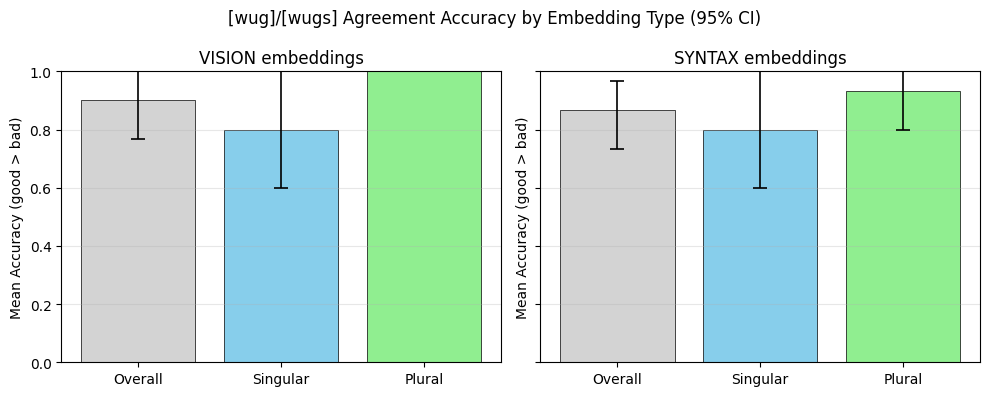


COMPARISON (95% bootstrap CI)
Metric                           Vision             Syntax
--------------------------------------------------------
Overall              0.900 [0.767,1.000] 0.867 [0.733,0.967]
Singular             0.800 [0.600,1.000] 0.800 [0.600,1.000]
Plural               1.000 [1.000,1.000] 0.933 [0.800,1.000]


In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 0. Add tokens ONCE
# ==========================================================
added_tokens = [" [wug]", " [wugs]"]
existing_vocab = lm.tokenizer.tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    lm.tokenizer.tokenizer.add_tokens(tokens_to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(tokens_to_add))
    print(f"Added tokens: {tokens_to_add}")
else:
    print("Tokens already in vocab")

# ==========================================================
# 1. Eval sentences
# ==========================================================
goods = [
    "The [wug] jumps across the rock while another watches.",
    "Two [wugs] climb over the fence together.",
    "I noticed the [wug] hiding behind the tree.",
    "Several [wugs] gather near the edge of the pond.",
    "A single [wug] was resting on the branch when I arrived.",
    "Dozens of [wugs] were waiting by the gate.",
    "The [wug] runs quickly toward its nest.",
    "The [wugs] scatter as soon as they hear the sound.",
    "One [wug] carries a small leaf in its mouth.",
    "Many [wugs] carry sticks to build their shelter.",
    "The [wug] in the corner looks nervous.",
    "The [wugs] near the river appear calm.",
    "That [wug] seems friendlier than the others.",
    "Those [wugs] seem unusually quiet today.",
    "The [wug] is glowing faintly under the lamp.",
    "The [wugs] are glowing with the same green light.",
    "Each [wug] moves in a slightly different way.",
    "All the [wugs] move as though synchronized.",
    "The [wug] beside the chair looks familiar.",
    "The [wugs] around the chair look identical.",
    "After the [wug] left, the noise stopped.",
    "After the [wugs] left, the garden felt empty.",
    "The [wug] eats until it can barely move.",
    "The [wugs] eat until the bowl is completely empty.",
    "If the [wug] hides, no one will notice.",
    "If the [wugs] hide, the forest becomes silent.",
    "The [wug] was playing before the rain started.",
    "The [wugs] were playing until it got dark.",
    "The [wug] sleeps while the others stay awake.",
    "The [wugs] sleep when the sun goes down."
]

bads = [
    "The [wugs] jumps across the rock while another watches.",
    "Two [wug] climb over the fence together.",
    "I noticed the [wugs] hiding behind the tree.",
    "Several [wug] gathers near the edge of the pond.",
    "A single [wugs] were resting on the branch when I arrived.",
    "Dozens of [wug] was waiting by the gate.",
    "The [wugs] runs quickly toward its nest.",
    "The [wug] scatter as soon as they hear the sound.",
    "One [wugs] carries a small leaf in its mouth.",
    "Many [wug] carry sticks to build their shelter.",
    "The [wugs] in the corner looks nervous.",
    "The [wug] near the river appear calm.",
    "That [wugs] seems friendlier than the others.",
    "Those [wug] seem unusually quiet today.",
    "The [wugs] is glowing faintly under the lamp.",
    "The [wug] are glowing with the same green light.",
    "Each [wugs] moves in a slightly different way.",
    "All the [wug] move as though synchronized.",
    "The [wugs] beside the chair looks familiar.",
    "The [wug] around the chair look identical.",
    "After the [wugs] left, the noise stopped.",
    "After the [wug] left, the garden felt empty.",
    "The [wugs] eats until it can barely move.",
    "The [wug] eat until the bowl is completely empty.",
    "If the [wugs] hides, no one will notice.",
    "If the [wug] hide, the forest becomes silent.",
    "The [wugs] was playing before the rain started.",
    "The [wug] were playing until it got dark.",
    "The [wugs] sleeps while the others stay awake.",
    "The [wug] sleep when the sun goes down."
]

singular_idx = [i for i, s in enumerate(goods) if " [wug]" in s]
plural_idx   = [i for i, s in enumerate(goods) if " [wugs]" in s]

# ==========================================================
# Helper: bootstrap 95% CI for accuracy
# ==========================================================
def bootstrap_ci(acc_vec, n_boot=10000, seed=42):
    """
    Given a 1-d array/tensor of 0s and 1s, return (mean, ci_low, ci_high)
    via percentile bootstrap.
    """
    rng = np.random.default_rng(seed)
    arr = np.asarray(acc_vec, dtype=np.float64)
    n = len(arr)
    boot_means = np.array([rng.choice(arr, size=n, replace=True).mean()
                           for _ in range(n_boot)])
    lo = np.percentile(boot_means, 2.5)
    hi = np.percentile(boot_means, 97.5)
    return arr.mean(), lo, hi

# ==========================================================
# 2. Run eval for each embedding condition
# ==========================================================

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"

all_results = {}

for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\n{'='*50}")
    print(f"Condition: {condition}")
    print(f"{'='*50}")

    # Load embeddings
    saved = torch.load(embed_path)
    emb = lm.model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)

    print(f"  Loaded {condition} embeddings")
    print(f"    [wug]  norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
    print(f"    [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")

    # Score
    good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
    bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]

    good_scores = lm.sequence_score(good_queries)
    bad_scores  = lm.sequence_score(bad_queries)

    diffs = torch.tensor(good_scores) - torch.tensor(bad_scores)
    acc_mask = (diffs > 0).float()

    # Bootstrap CIs
    overall_mean, overall_lo, overall_hi = bootstrap_ci(acc_mask)
    sing_mean, sing_lo, sing_hi = bootstrap_ci(acc_mask[singular_idx])
    plur_mean, plur_lo, plur_hi = bootstrap_ci(acc_mask[plural_idx])

    print(f"  Overall accuracy:  {overall_mean:.3f}  [{overall_lo:.3f}, {overall_hi:.3f}]")
    print(f"  Singular accuracy: {sing_mean:.3f}  [{sing_lo:.3f}, {sing_hi:.3f}]")
    print(f"  Plural accuracy:   {plur_mean:.3f}  [{plur_lo:.3f}, {plur_hi:.3f}]")

    all_results[condition] = {
        "overall": overall_mean,
        "singular": sing_mean,
        "plural": plur_mean,
        "overall_ci": (overall_lo, overall_hi),
        "singular_ci": (sing_lo, sing_hi),
        "plural_ci": (plur_lo, plur_hi),
        "diffs": diffs,
        "acc_mask": acc_mask,
    }

# ==========================================================
# 3. Plot side by side with 95% CI error bars
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, condition in zip(axes, ["vision", "syntax"]):
    r = all_results[condition]
    means = [r["overall"], r["singular"], r["plural"]]
    # Error bars: distance from mean to lower/upper bound
    ci_lo = [r["overall_ci"][0], r["singular_ci"][0], r["plural_ci"][0]]
    ci_hi = [r["overall_ci"][1], r["singular_ci"][1], r["plural_ci"][1]]
    yerr_lo = [m - lo for m, lo in zip(means, ci_lo)]
    yerr_hi = [hi - m for m, hi in zip(means, ci_hi)]

    bars = ax.bar(["Overall", "Singular", "Plural"], means,
                  color=["lightgray", "skyblue", "lightgreen"],
                  edgecolor="black", linewidth=0.5)
    ax.errorbar(["Overall", "Singular", "Plural"], means,
                yerr=[yerr_lo, yerr_hi],
                fmt="none", ecolor="black", capsize=5, capthick=1.2, linewidth=1.2)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Mean Accuracy (good > bad)")
    ax.set_title(f"{condition.upper()} embeddings")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("[wug]/[wugs] Agreement Accuracy by Embedding Type (95% CI)")
plt.tight_layout()
plt.show()

# ==========================================================
# 4. Print comparison
# ==========================================================

print(f"\n{'='*60}")
print(f"COMPARISON (95% bootstrap CI)")
print(f"{'='*60}")
print(f"{'Metric':<20} {'Vision':>18} {'Syntax':>18}")
print(f"{'-'*56}")
for metric in ["overall", "singular", "plural"]:
    v = all_results["vision"]
    s = all_results["syntax"]
    v_str = f"{v[metric]:.3f} [{v[metric+'_ci'][0]:.3f},{v[metric+'_ci'][1]:.3f}]"
    s_str = f"{s[metric]:.3f} [{s[metric+'_ci'][0]:.3f},{s[metric+'_ci'][1]:.3f}]"
    print(f"{metric.capitalize():<20} {v_str:>18} {s_str:>18}")

And then let's do some held out from BLiMP

Tokens already in vocab

Condition: VISION
  Loaded vision embeddings
    [wug]  norm: 1.0781
    [wugs] norm: 1.0781

  NATURAL eval:
    Overall:  0.900
    Singular: 0.800
    Plural:   1.000

  BLIMP eval:
    Overall:  0.940
    Singular: 0.880
    Plural:   1.000

Condition: SYNTAX
  Loaded syntax embeddings
    [wug]  norm: 1.3906
    [wugs] norm: 1.3203

  NATURAL eval:
    Overall:  0.867
    Singular: 0.800
    Plural:   0.933

  BLIMP eval:
    Overall:  0.920
    Singular: 1.000
    Plural:   0.840


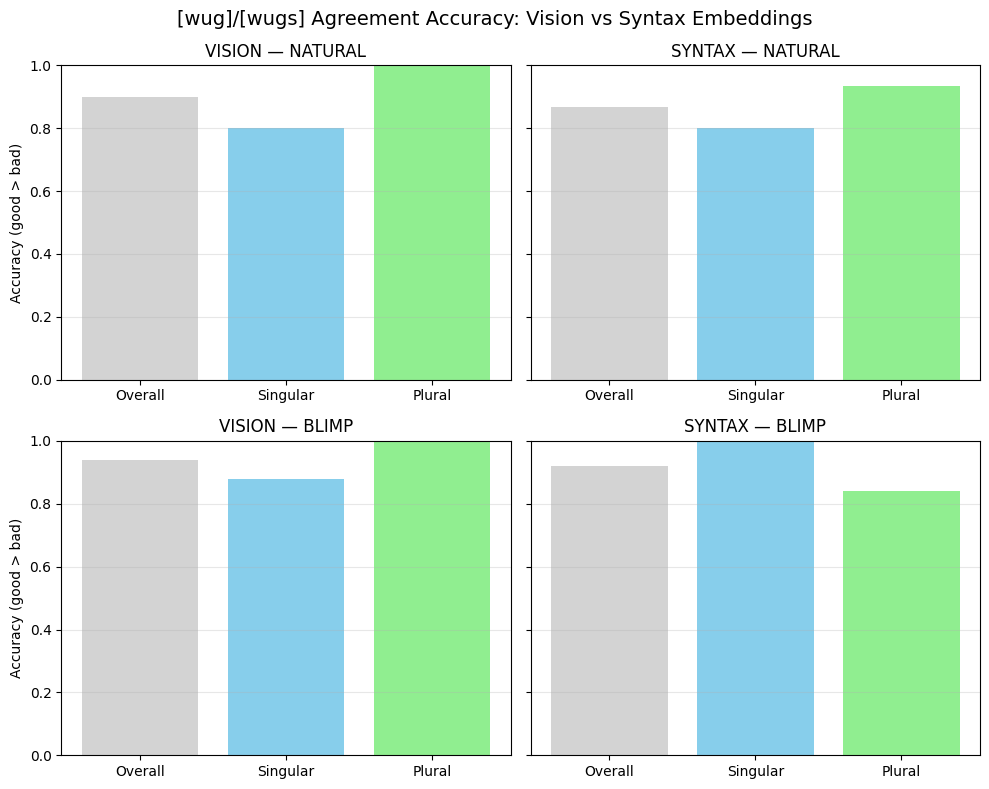


SUMMARY
Eval       Metric           Vision     Syntax
------------------------------------------
natural    overall           0.900      0.867
natural    singular          0.800      0.800
natural    plural            1.000      0.933
------------------------------------------
blimp      overall           0.940      0.920
blimp      singular          0.880      1.000
blimp      plural            1.000      0.840
------------------------------------------


In [5]:
import torch
import matplotlib.pyplot as plt

# ==========================================================
# 0. Add tokens ONCE
# ==========================================================
added_tokens = [" [wug]", " [wugs]"]
existing_vocab = lm.tokenizer.tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    lm.tokenizer.tokenizer.add_tokens(tokens_to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(tokens_to_add))
    print(f"Added tokens: {tokens_to_add}")
else:
    print("Tokens already in vocab")

# ==========================================================
# 1. Both eval sets
# ==========================================================

# --- Eval Set A: Naturalistic ---
goods_natural = [
    "The [wug] jumps across the rock while another watches.",
    "Two [wugs] climb over the fence together.",
    "I noticed the [wug] hiding behind the tree.",
    "Several [wugs] gather near the edge of the pond.",
    "A single [wug] was resting on the branch when I arrived.",
    "Dozens of [wugs] were waiting by the gate.",
    "The [wug] runs quickly toward its nest.",
    "The [wugs] scatter as soon as they hear the sound.",
    "One [wug] carries a small leaf in its mouth.",
    "Many [wugs] carry sticks to build their shelter.",
    "The [wug] in the corner looks nervous.",
    "The [wugs] near the river appear calm.",
    "That [wug] seems friendlier than the others.",
    "Those [wugs] seem unusually quiet today.",
    "The [wug] is glowing faintly under the lamp.",
    "The [wugs] are glowing with the same green light.",
    "Each [wug] moves in a slightly different way.",
    "All the [wugs] move as though synchronized.",
    "The [wug] beside the chair looks familiar.",
    "The [wugs] around the chair look identical.",
    "After the [wug] left, the noise stopped.",
    "After the [wugs] left, the garden felt empty.",
    "The [wug] eats until it can barely move.",
    "The [wugs] eat until the bowl is completely empty.",
    "If the [wug] hides, no one will notice.",
    "If the [wugs] hide, the forest becomes silent.",
    "The [wug] was playing before the rain started.",
    "The [wugs] were playing until it got dark.",
    "The [wug] sleeps while the others stay awake.",
    "The [wugs] sleep when the sun goes down."
]

bads_natural = [
    "The [wugs] jumps across the rock while another watches.",
    "Two [wug] climb over the fence together.",
    "I noticed the [wugs] hiding behind the tree.",
    "Several [wug] gathers near the edge of the pond.",
    "A single [wugs] were resting on the branch when I arrived.",
    "Dozens of [wug] was waiting by the gate.",
    "The [wugs] runs quickly toward its nest.",
    "The [wug] scatter as soon as they hear the sound.",
    "One [wugs] carries a small leaf in its mouth.",
    "Many [wug] carry sticks to build their shelter.",
    "The [wugs] in the corner looks nervous.",
    "The [wug] near the river appear calm.",
    "That [wugs] seems friendlier than the others.",
    "Those [wug] seem unusually quiet today.",
    "The [wugs] is glowing faintly under the lamp.",
    "The [wug] are glowing with the same green light.",
    "Each [wugs] moves in a slightly different way.",
    "All the [wug] move as though synchronized.",
    "The [wugs] beside the chair looks familiar.",
    "The [wug] around the chair look identical.",
    "After the [wugs] left, the noise stopped.",
    "After the [wug] left, the garden felt empty.",
    "The [wugs] eats until it can barely move.",
    "The [wug] eat until the bowl is completely empty.",
    "If the [wugs] hides, no one will notice.",
    "If the [wug] hide, the forest becomes silent.",
    "The [wugs] was playing before the rain started.",
    "The [wug] were playing until it got dark.",
    "The [wugs] sleeps while the others stay awake.",
    "The [wug] sleep when the sun goes down."
]

# --- Eval Set B: BLiMP-style ---
goods_blimp = [
    "The [wug] compromises.",
    "The [wug] marries.",
    "The [wug] hasn't whispered.",
    "The [wug] isn't working hard.",
    "The [wug] appreciates all teenagers.",
    "The [wug] wasn't murmuring.",
    "The [wug] wasn't hurting Ellen.",
    "The [wug] knows Larry.",
    "The [wug] hasn't testified.",
    "The [wug] hasn't debated.",
    "The [wug] has talked to Angela.",
    "The [wug] hasn't ascended that mountain.",
    "The [wug] smiles.",
    "The [wug] cheers.",
    "The [wug] distracts Suzanne.",
    "The [wug] watches Kristin.",
    "The [wug] wasn't fleeing from Michael.",
    "The [wug] has profited.",
    "The [wug] hasn't shrunk.",
    "The [wug] was boasting.",
    "The [wug] doesn't complain.",
    "The [wug] has vanished.",
    "The [wug] wasn't laughing.",
    "The [wug] admires the teacher.",
    "The [wug] has explored the cave.",
    "The [wugs] compromise.",
    "The [wugs] marry.",
    "The [wugs] haven't whispered.",
    "The [wugs] aren't working hard.",
    "The [wugs] appreciate all teenagers.",
    "The [wugs] weren't murmuring.",
    "The [wugs] weren't hurting Ellen.",
    "The [wugs] know Larry.",
    "The [wugs] haven't testified.",
    "The [wugs] haven't debated.",
    "The [wugs] have talked to Angela.",
    "The [wugs] haven't ascended that mountain.",
    "The [wugs] smile.",
    "The [wugs] cheer.",
    "The [wugs] distract Suzanne.",
    "The [wugs] watch Kristin.",
    "The [wugs] weren't fleeing from Michael.",
    "The [wugs] have profited.",
    "The [wugs] haven't shrunk.",
    "The [wugs] were boasting.",
    "The [wugs] don't complain.",
    "The [wugs] have vanished.",
    "The [wugs] weren't laughing.",
    "The [wugs] admire the teacher.",
    "The [wugs] have explored the cave.",
]

bads_blimp = [
    "The [wugs] compromises.",
    "The [wugs] marries.",
    "The [wugs] hasn't whispered.",
    "The [wugs] isn't working hard.",
    "The [wugs] appreciates all teenagers.",
    "The [wugs] wasn't murmuring.",
    "The [wugs] wasn't hurting Ellen.",
    "The [wugs] knows Larry.",
    "The [wugs] hasn't testified.",
    "The [wugs] hasn't debated.",
    "The [wugs] has talked to Angela.",
    "The [wugs] hasn't ascended that mountain.",
    "The [wugs] smiles.",
    "The [wugs] cheers.",
    "The [wugs] distracts Suzanne.",
    "The [wugs] watches Kristin.",
    "The [wugs] wasn't fleeing from Michael.",
    "The [wugs] has profited.",
    "The [wugs] hasn't shrunk.",
    "The [wugs] was boasting.",
    "The [wugs] doesn't complain.",
    "The [wugs] has vanished.",
    "The [wugs] wasn't laughing.",
    "The [wugs] admires the teacher.",
    "The [wugs] has explored the cave.",
    "The [wug] compromise.",
    "The [wug] marry.",
    "The [wug] haven't whispered.",
    "The [wug] aren't working hard.",
    "The [wug] appreciate all teenagers.",
    "The [wug] weren't murmuring.",
    "The [wug] weren't hurting Ellen.",
    "The [wug] know Larry.",
    "The [wug] haven't testified.",
    "The [wug] haven't debated.",
    "The [wug] have talked to Angela.",
    "The [wug] haven't ascended that mountain.",
    "The [wug] smile.",
    "The [wug] cheer.",
    "The [wug] distract Suzanne.",
    "The [wug] watch Kristin.",
    "The [wug] weren't fleeing from Michael.",
    "The [wug] have profited.",
    "The [wug] haven't shrunk.",
    "The [wug] were boasting.",
    "The [wug] don't complain.",
    "The [wug] have vanished.",
    "The [wug] weren't laughing.",
    "The [wug] admire the teacher.",
    "The [wug] have explored the cave.",
]

assert len(goods_natural) == len(bads_natural)
assert len(goods_blimp) == len(bads_blimp)

# ==========================================================
# 2. Run eval for each embedding × eval set
# ==========================================================

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"

all_results = {}

for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\n{'='*60}")
    print(f"Condition: {condition.upper()}")
    print(f"{'='*60}")
    
    # Load embeddings
    saved = torch.load(embed_path)
    emb = lm.model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    
    print(f"  Loaded {condition} embeddings")
    print(f"    [wug]  norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
    print(f"    [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")
    
    all_results[condition] = {}
    
    for eval_name, goods, bads in [("natural", goods_natural, bads_natural), 
                                     ("blimp", goods_blimp, bads_blimp)]:
        good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
        bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]
        
        good_scores = lm.sequence_score(good_queries)
        bad_scores  = lm.sequence_score(bad_queries)
        
        diffs = torch.tensor(good_scores) - torch.tensor(bad_scores)
        acc_mask = (diffs > 0).float()
        
        singular_idx = [i for i, s in enumerate(goods) if " [wug]" in s]
        plural_idx   = [i for i, s in enumerate(goods) if " [wugs]" in s]
        
        overall_acc = acc_mask.mean().item()
        sing_acc = acc_mask[singular_idx].mean().item()
        plur_acc = acc_mask[plural_idx].mean().item()
        
        print(f"\n  {eval_name.upper()} eval:")
        print(f"    Overall:  {overall_acc:.3f}")
        print(f"    Singular: {sing_acc:.3f}")
        print(f"    Plural:   {plur_acc:.3f}")
        
        all_results[condition][eval_name] = {
            "overall": overall_acc,
            "singular": sing_acc,
            "plural": plur_acc,
        }

# ==========================================================
# 3. Plot 2x2 grid
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

for col, condition in enumerate(["vision", "syntax"]):
    for row, eval_name in enumerate(["natural", "blimp"]):
        ax = axes[row][col]
        r = all_results[condition][eval_name]
        ax.bar(["Overall", "Singular", "Plural"],
               [r["overall"], r["singular"], r["plural"]],
               color=["lightgray", "skyblue", "lightgreen"])
        ax.set_ylim(0, 1)
        ax.set_title(f"{condition.upper()} — {eval_name.upper()}")
        ax.grid(axis="y", alpha=0.3)
        if col == 0:
            ax.set_ylabel("Accuracy (good > bad)")

plt.suptitle("[wug]/[wugs] Agreement Accuracy: Vision vs Syntax Embeddings", fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================================
# 4. Summary table
# ==========================================================

print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"{'Eval':<10} {'Metric':<12} {'Vision':>10} {'Syntax':>10}")
print(f"{'-'*42}")
for eval_name in ["natural", "blimp"]:
    for metric in ["overall", "singular", "plural"]:
        v = all_results["vision"][eval_name][metric]
        s = all_results["syntax"][eval_name][metric]
        print(f"{eval_name:<10} {metric:<12} {v:>10.3f} {s:>10.3f}")
    print(f"{'-'*42}")

# DAS TRAINING STIMULI

In [7]:
pp_pairs = [
    # from (25)
    {"singular": "The [wug] from Japan", "plural": "The [wugs] from Japan"},
    {"singular": "The [wug] from France", "plural": "The [wugs] from France"},
    {"singular": "The [wug] from Rome", "plural": "The [wugs] from Rome"},
    {"singular": "The [wug] from Mars", "plural": "The [wugs] from Mars"},
    {"singular": "The [wug] from home", "plural": "The [wugs] from home"},
    {"singular": "The [wug] from birth", "plural": "The [wugs] from birth"},
    {"singular": "The [wug] from war", "plural": "The [wugs] from war"},
    {"singular": "The [wug] from school", "plural": "The [wugs] from school"},
    {"singular": "The [wug] from church", "plural": "The [wugs] from church"},
    {"singular": "The [wug] from court", "plural": "The [wugs] from court"},
    {"singular": "The [wug] from sea", "plural": "The [wugs] from sea"},
    {"singular": "The [wug] from hell", "plural": "The [wugs] from hell"},
    {"singular": "The [wug] from work", "plural": "The [wugs] from work"},
    {"singular": "The [wug] from dawn", "plural": "The [wugs] from dawn"},
    {"singular": "The [wug] from dusk", "plural": "The [wugs] from dusk"},
    {"singular": "The [wug] from Spain", "plural": "The [wugs] from Spain"},
    {"singular": "The [wug] from China", "plural": "The [wugs] from China"},
    {"singular": "The [wug] from Peru", "plural": "The [wugs] from Peru"},
    {"singular": "The [wug] from space", "plural": "The [wugs] from space"},
    {"singular": "The [wug] from town", "plural": "The [wugs] from town"},
    {"singular": "The [wug] from Greece", "plural": "The [wugs] from Greece"},
    {"singular": "The [wug] from Chad", "plural": "The [wugs] from Chad"},
    {"singular": "The [wug] from York", "plural": "The [wugs] from York"},
    {"singular": "The [wug] from Wales", "plural": "The [wugs] from Wales"},
    {"singular": "The [wug] from Kent", "plural": "The [wugs] from Kent"},
    # near (25)
    {"singular": "The [wug] near Japan", "plural": "The [wugs] near Japan"},
    {"singular": "The [wug] near France", "plural": "The [wugs] near France"},
    {"singular": "The [wug] near Rome", "plural": "The [wugs] near Rome"},
    {"singular": "The [wug] near Mars", "plural": "The [wugs] near Mars"},
    {"singular": "The [wug] near home", "plural": "The [wugs] near home"},
    {"singular": "The [wug] near school", "plural": "The [wugs] near school"},
    {"singular": "The [wug] near church", "plural": "The [wugs] near church"},
    {"singular": "The [wug] near court", "plural": "The [wugs] near court"},
    {"singular": "The [wug] near sea", "plural": "The [wugs] near sea"},
    {"singular": "The [wug] near land", "plural": "The [wugs] near land"},
    {"singular": "The [wug] near work", "plural": "The [wugs] near work"},
    {"singular": "The [wug] near town", "plural": "The [wugs] near town"},
    {"singular": "The [wug] near Spain", "plural": "The [wugs] near Spain"},
    {"singular": "The [wug] near China", "plural": "The [wugs] near China"},
    {"singular": "The [wug] near Peru", "plural": "The [wugs] near Peru"},
    {"singular": "The [wug] near space", "plural": "The [wugs] near space"},
    {"singular": "The [wug] near dawn", "plural": "The [wugs] near dawn"},
    {"singular": "The [wug] near dusk", "plural": "The [wugs] near dusk"},
    {"singular": "The [wug] near hell", "plural": "The [wugs] near hell"},
    {"singular": "The [wug] near birth", "plural": "The [wugs] near birth"},
    {"singular": "The [wug] near Greece", "plural": "The [wugs] near Greece"},
    {"singular": "The [wug] near Chad", "plural": "The [wugs] near Chad"},
    {"singular": "The [wug] near York", "plural": "The [wugs] near York"},
    {"singular": "The [wug] near Wales", "plural": "The [wugs] near Wales"},
    {"singular": "The [wug] near Kent", "plural": "The [wugs] near Kent"},
    # past (25)
    {"singular": "The [wug] past dawn", "plural": "The [wugs] past dawn"},
    {"singular": "The [wug] past dusk", "plural": "The [wugs] past dusk"},
    {"singular": "The [wug] past noon", "plural": "The [wugs] past noon"},
    {"singular": "The [wug] past night", "plural": "The [wugs] past night"},
    {"singular": "The [wug] past lunch", "plural": "The [wugs] past lunch"},
    {"singular": "The [wug] past death", "plural": "The [wugs] past death"},
    {"singular": "The [wug] past Rome", "plural": "The [wugs] past Rome"},
    {"singular": "The [wug] past home", "plural": "The [wugs] past home"},
    {"singular": "The [wug] past school", "plural": "The [wugs] past school"},
    {"singular": "The [wug] past church", "plural": "The [wugs] past church"},
    {"singular": "The [wug] past court", "plural": "The [wugs] past court"},
    {"singular": "The [wug] past work", "plural": "The [wugs] past work"},
    {"singular": "The [wug] past town", "plural": "The [wugs] past town"},
    {"singular": "The [wug] past Spain", "plural": "The [wugs] past Spain"},
    {"singular": "The [wug] past France", "plural": "The [wugs] past France"},
    {"singular": "The [wug] past Mars", "plural": "The [wugs] past Mars"},
    {"singular": "The [wug] past war", "plural": "The [wugs] past war"},
    {"singular": "The [wug] past rest", "plural": "The [wugs] past rest"},
    {"singular": "The [wug] past peace", "plural": "The [wugs] past peace"},
    {"singular": "The [wug] past hell", "plural": "The [wugs] past hell"},
    {"singular": "The [wug] past Greece", "plural": "The [wugs] past Greece"},
    {"singular": "The [wug] past Chad", "plural": "The [wugs] past Chad"},
    {"singular": "The [wug] past York", "plural": "The [wugs] past York"},
    {"singular": "The [wug] past Wales", "plural": "The [wugs] past Wales"},
    {"singular": "The [wug] past Kent", "plural": "The [wugs] past Kent"},
    # in (25)
    {"singular": "The [wug] in Japan", "plural": "The [wugs] in Japan"},
    {"singular": "The [wug] in France", "plural": "The [wugs] in France"},
    {"singular": "The [wug] in Rome", "plural": "The [wugs] in Rome"},
    {"singular": "The [wug] in Spain", "plural": "The [wugs] in Spain"},
    {"singular": "The [wug] in China", "plural": "The [wugs] in China"},
    {"singular": "The [wug] in Peru", "plural": "The [wugs] in Peru"},
    {"singular": "The [wug] in space", "plural": "The [wugs] in space"},
    {"singular": "The [wug] in school", "plural": "The [wugs] in school"},
    {"singular": "The [wug] in church", "plural": "The [wugs] in church"},
    {"singular": "The [wug] in court", "plural": "The [wugs] in court"},
    {"singular": "The [wug] in war", "plural": "The [wugs] in war"},
    {"singular": "The [wug] in hell", "plural": "The [wugs] in hell"},
    {"singular": "The [wug] in town", "plural": "The [wugs] in town"},
    {"singular": "The [wug] in work", "plural": "The [wugs] in work"},
    {"singular": "The [wug] in rest", "plural": "The [wugs] in rest"},
    {"singular": "The [wug] in peace", "plural": "The [wugs] in peace"},
    {"singular": "The [wug] in love", "plural": "The [wugs] in love"},
    {"singular": "The [wug] in pain", "plural": "The [wugs] in pain"},
    {"singular": "The [wug] in need", "plural": "The [wugs] in need"},
    {"singular": "The [wug] in debt", "plural": "The [wugs] in debt"},
    {"singular": "The [wug] in Greece", "plural": "The [wugs] in Greece"},
    {"singular": "The [wug] in Chad", "plural": "The [wugs] in Chad"},
    {"singular": "The [wug] in York", "plural": "The [wugs] in York"},
    {"singular": "The [wug] in Wales", "plural": "The [wugs] in Wales"},
    {"singular": "The [wug] in Kent", "plural": "The [wugs] in Kent"},
    # on (25)
    {"singular": "The [wug] on Mars", "plural": "The [wugs] on Mars"},
    {"singular": "The [wug] on land", "plural": "The [wugs] on land"},
    {"singular": "The [wug] on sea", "plural": "The [wugs] on sea"},
    {"singular": "The [wug] on shore", "plural": "The [wugs] on shore"},
    {"singular": "The [wug] on top", "plural": "The [wugs] on top"},
    {"singular": "The [wug] on stage", "plural": "The [wugs] on stage"},
    {"singular": "The [wug] on film", "plural": "The [wugs] on film"},
    {"singular": "The [wug] on ice", "plural": "The [wugs] on ice"},
    {"singular": "The [wug] on fire", "plural": "The [wugs] on fire"},
    {"singular": "The [wug] on guard", "plural": "The [wugs] on guard"},
    {"singular": "The [wug] on watch", "plural": "The [wugs] on watch"},
    {"singular": "The [wug] on leave", "plural": "The [wugs] on leave"},
    {"singular": "The [wug] on loan", "plural": "The [wugs] on loan"},
    {"singular": "The [wug] on trial", "plural": "The [wugs] on trial"},
    {"singular": "The [wug] on strike", "plural": "The [wugs] on strike"},
    {"singular": "The [wug] on drugs", "plural": "The [wugs] on drugs"},
    {"singular": "The [wug] on call", "plural": "The [wugs] on call"},
    {"singular": "The [wug] on sale", "plural": "The [wugs] on sale"},
    {"singular": "The [wug] on site", "plural": "The [wugs] on site"},
    {"singular": "The [wug] on hold", "plural": "The [wugs] on hold"},
    {"singular": "The [wug] on edge", "plural": "The [wugs] on edge"},
    {"singular": "The [wug] on foot", "plural": "The [wugs] on foot"},
    {"singular": "The [wug] on deck", "plural": "The [wugs] on deck"},
    {"singular": "The [wug] on tape", "plural": "The [wugs] on tape"},
    {"singular": "The [wug] on track", "plural": "The [wugs] on track"},
    # by (25)
    {"singular": "The [wug] by Rome", "plural": "The [wugs] by Rome"},
    {"singular": "The [wug] by Spain", "plural": "The [wugs] by Spain"},
    {"singular": "The [wug] by France", "plural": "The [wugs] by France"},
    {"singular": "The [wug] by China", "plural": "The [wugs] by China"},
    {"singular": "The [wug] by home", "plural": "The [wugs] by home"},
    {"singular": "The [wug] by school", "plural": "The [wugs] by school"},
    {"singular": "The [wug] by church", "plural": "The [wugs] by church"},
    {"singular": "The [wug] by sea", "plural": "The [wugs] by sea"},
    {"singular": "The [wug] by land", "plural": "The [wugs] by land"},
    {"singular": "The [wug] by dawn", "plural": "The [wugs] by dawn"},
    {"singular": "The [wug] by dusk", "plural": "The [wugs] by dusk"},
    {"singular": "The [wug] by noon", "plural": "The [wugs] by noon"},
    {"singular": "The [wug] by night", "plural": "The [wugs] by night"},
    {"singular": "The [wug] by birth", "plural": "The [wugs] by birth"},
    {"singular": "The [wug] by trade", "plural": "The [wugs] by trade"},
    {"singular": "The [wug] by force", "plural": "The [wugs] by force"},
    {"singular": "The [wug] by luck", "plural": "The [wugs] by luck"},
    {"singular": "The [wug] by law", "plural": "The [wugs] by law"},
    {"singular": "The [wug] by choice", "plural": "The [wugs] by choice"},
    {"singular": "The [wug] by chance", "plural": "The [wugs] by chance"},
    {"singular": "The [wug] by Greece", "plural": "The [wugs] by Greece"},
    {"singular": "The [wug] by Chad", "plural": "The [wugs] by Chad"},
    {"singular": "The [wug] by York", "plural": "The [wugs] by York"},
    {"singular": "The [wug] by Wales", "plural": "The [wugs] by Wales"},
    {"singular": "The [wug] by Kent", "plural": "The [wugs] by Kent"},
    # at (25)
    {"singular": "The [wug] at home", "plural": "The [wugs] at home"},
    {"singular": "The [wug] at school", "plural": "The [wugs] at school"},
    {"singular": "The [wug] at church", "plural": "The [wugs] at church"},
    {"singular": "The [wug] at court", "plural": "The [wugs] at court"},
    {"singular": "The [wug] at work", "plural": "The [wugs] at work"},
    {"singular": "The [wug] at sea", "plural": "The [wugs] at sea"},
    {"singular": "The [wug] at war", "plural": "The [wugs] at war"},
    {"singular": "The [wug] at rest", "plural": "The [wugs] at rest"},
    {"singular": "The [wug] at peace", "plural": "The [wugs] at peace"},
    {"singular": "The [wug] at dawn", "plural": "The [wugs] at dawn"},
    {"singular": "The [wug] at dusk", "plural": "The [wugs] at dusk"},
    {"singular": "The [wug] at noon", "plural": "The [wugs] at noon"},
    {"singular": "The [wug] at night", "plural": "The [wugs] at night"},
    {"singular": "The [wug] at lunch", "plural": "The [wugs] at lunch"},
    {"singular": "The [wug] at birth", "plural": "The [wugs] at birth"},
    {"singular": "The [wug] at death", "plural": "The [wugs] at death"},
    {"singular": "The [wug] at risk", "plural": "The [wugs] at risk"},
    {"singular": "The [wug] at fault", "plural": "The [wugs] at fault"},
    {"singular": "The [wug] at large", "plural": "The [wugs] at large"},
    {"singular": "The [wug] at stake", "plural": "The [wugs] at stake"},
    {"singular": "The [wug] at best", "plural": "The [wugs] at best"},
    {"singular": "The [wug] at last", "plural": "The [wugs] at last"},
    {"singular": "The [wug] at ease", "plural": "The [wugs] at ease"},
    {"singular": "The [wug] at bay", "plural": "The [wugs] at bay"},
    {"singular": "The [wug] at play", "plural": "The [wugs] at play"},
    # like (25)
    {"singular": "The [wug] like him", "plural": "The [wugs] like him"},
    {"singular": "The [wug] like her", "plural": "The [wugs] like her"},
    {"singular": "The [wug] like them", "plural": "The [wugs] like them"},
    {"singular": "The [wug] like us", "plural": "The [wugs] like us"},
    {"singular": "The [wug] like me", "plural": "The [wugs] like me"},
    {"singular": "The [wug] like you", "plural": "The [wugs] like you"},
    {"singular": "The [wug] like that", "plural": "The [wugs] like that"},
    {"singular": "The [wug] like this", "plural": "The [wugs] like this"},
    {"singular": "The [wug] like Rex", "plural": "The [wugs] like Rex"},
    {"singular": "The [wug] like Tom", "plural": "The [wugs] like Tom"},
    {"singular": "The [wug] like Sam", "plural": "The [wugs] like Sam"},
    {"singular": "The [wug] like Max", "plural": "The [wugs] like Max"},
    {"singular": "The [wug] like Joe", "plural": "The [wugs] like Joe"},
    {"singular": "The [wug] like Dan", "plural": "The [wugs] like Dan"},
    {"singular": "The [wug] like God", "plural": "The [wugs] like God"},
    {"singular": "The [wug] like ice", "plural": "The [wugs] like ice"},
    {"singular": "The [wug] like fire", "plural": "The [wugs] like fire"},
    {"singular": "The [wug] like stone", "plural": "The [wugs] like stone"},
    {"singular": "The [wug] like gold", "plural": "The [wugs] like gold"},
    {"singular": "The [wug] like steel", "plural": "The [wugs] like steel"},
    {"singular": "The [wug] like glass", "plural": "The [wugs] like glass"},
    {"singular": "The [wug] like silk", "plural": "The [wugs] like silk"},
    {"singular": "The [wug] like clay", "plural": "The [wugs] like clay"},
    {"singular": "The [wug] like ash", "plural": "The [wugs] like ash"},
    {"singular": "The [wug] like dust", "plural": "The [wugs] like dust"},
    # with (25)
    {"singular": "The [wug] with him", "plural": "The [wugs] with him"},
    {"singular": "The [wug] with her", "plural": "The [wugs] with her"},
    {"singular": "The [wug] with them", "plural": "The [wugs] with them"},
    {"singular": "The [wug] with us", "plural": "The [wugs] with us"},
    {"singular": "The [wug] with me", "plural": "The [wugs] with me"},
    {"singular": "The [wug] with you", "plural": "The [wugs] with you"},
    {"singular": "The [wug] with Rex", "plural": "The [wugs] with Rex"},
    {"singular": "The [wug] with Tom", "plural": "The [wugs] with Tom"},
    {"singular": "The [wug] with Sam", "plural": "The [wugs] with Sam"},
    {"singular": "The [wug] with Max", "plural": "The [wugs] with Max"},
    {"singular": "The [wug] with Joe", "plural": "The [wugs] with Joe"},
    {"singular": "The [wug] with Dan", "plural": "The [wugs] with Dan"},
    {"singular": "The [wug] with God", "plural": "The [wugs] with God"},
    {"singular": "The [wug] with grace", "plural": "The [wugs] with grace"},
    {"singular": "The [wug] with pride", "plural": "The [wugs] with pride"},
    {"singular": "The [wug] with care", "plural": "The [wugs] with care"},
    {"singular": "The [wug] with love", "plural": "The [wugs] with love"},
    {"singular": "The [wug] with rage", "plural": "The [wugs] with rage"},
    {"singular": "The [wug] with fear", "plural": "The [wugs] with fear"},
    {"singular": "The [wug] with pain", "plural": "The [wugs] with pain"},
    {"singular": "The [wug] with glee", "plural": "The [wugs] with glee"},
    {"singular": "The [wug] with hope", "plural": "The [wugs] with hope"},
    {"singular": "The [wug] with spite", "plural": "The [wugs] with spite"},
    {"singular": "The [wug] with charm", "plural": "The [wugs] with charm"},
    {"singular": "The [wug] with skill", "plural": "The [wugs] with skill"},
    # for (25)
    {"singular": "The [wug] for sale", "plural": "The [wugs] for sale"},
    {"singular": "The [wug] for hire", "plural": "The [wugs] for hire"},
    {"singular": "The [wug] for free", "plural": "The [wugs] for free"},
    {"singular": "The [wug] for show", "plural": "The [wugs] for show"},
    {"singular": "The [wug] for fun", "plural": "The [wugs] for fun"},
    {"singular": "The [wug] for sport", "plural": "The [wugs] for sport"},
    {"singular": "The [wug] for keeps", "plural": "The [wugs] for keeps"},
    {"singular": "The [wug] for life", "plural": "The [wugs] for life"},
    {"singular": "The [wug] for war", "plural": "The [wugs] for war"},
    {"singular": "The [wug] for peace", "plural": "The [wugs] for peace"},
    {"singular": "The [wug] for him", "plural": "The [wugs] for him"},
    {"singular": "The [wug] for her", "plural": "The [wugs] for her"},
    {"singular": "The [wug] for them", "plural": "The [wugs] for them"},
    {"singular": "The [wug] for us", "plural": "The [wugs] for us"},
    {"singular": "The [wug] for me", "plural": "The [wugs] for me"},
    {"singular": "The [wug] for you", "plural": "The [wugs] for you"},
    {"singular": "The [wug] for Tom", "plural": "The [wugs] for Tom"},
    {"singular": "The [wug] for Sam", "plural": "The [wugs] for Sam"},
    {"singular": "The [wug] for Max", "plural": "The [wugs] for Max"},
    {"singular": "The [wug] for Rex", "plural": "The [wugs] for Rex"},
    {"singular": "The [wug] for Joe", "plural": "The [wugs] for Joe"},
    {"singular": "The [wug] for Dan", "plural": "The [wugs] for Dan"},
    {"singular": "The [wug] for God", "plural": "The [wugs] for God"},
    {"singular": "The [wug] for food", "plural": "The [wugs] for food"},
    {"singular": "The [wug] for gold", "plural": "The [wugs] for gold"},
    # off (25)
    {"singular": "The [wug] off Mars", "plural": "The [wugs] off Mars"},
    {"singular": "The [wug] off land", "plural": "The [wugs] off land"},
    {"singular": "The [wug] off shore", "plural": "The [wugs] off shore"},
    {"singular": "The [wug] off stage", "plural": "The [wugs] off stage"},
    {"singular": "The [wug] off guard", "plural": "The [wugs] off guard"},
    {"singular": "The [wug] off duty", "plural": "The [wugs] off duty"},
    {"singular": "The [wug] off track", "plural": "The [wugs] off track"},
    {"singular": "The [wug] off base", "plural": "The [wugs] off base"},
    {"singular": "The [wug] off site", "plural": "The [wugs] off site"},
    {"singular": "The [wug] off course", "plural": "The [wugs] off course"},
    {"singular": "The [wug] off pace", "plural": "The [wugs] off pace"},
    {"singular": "The [wug] off screen", "plural": "The [wugs] off screen"},
    {"singular": "The [wug] off peak", "plural": "The [wugs] off peak"},
    {"singular": "The [wug] off grid", "plural": "The [wugs] off grid"},
    {"singular": "The [wug] off lease", "plural": "The [wugs] off lease"},
    {"singular": "The [wug] off key", "plural": "The [wugs] off key"},
    {"singular": "The [wug] off road", "plural": "The [wugs] off road"},
    {"singular": "The [wug] off drugs", "plural": "The [wugs] off drugs"},
    {"singular": "The [wug] off script", "plural": "The [wugs] off script"},
    {"singular": "The [wug] off call", "plural": "The [wugs] off call"},
    {"singular": "The [wug] off trail", "plural": "The [wugs] off trail"},
    {"singular": "The [wug] off line", "plural": "The [wugs] off line"},
    {"singular": "The [wug] off work", "plural": "The [wugs] off work"},
    {"singular": "The [wug] off ice", "plural": "The [wugs] off ice"},
    {"singular": "The [wug] off form", "plural": "The [wugs] off form"},
]

print(f"Total PP pairs: {len(pp_pairs)}")

Total PP pairs: 275


In [8]:
rc_obj_pairs = [
    # he
    {"singular": "The [wug] he saw", "plural": "The [wugs] he saw"},
    {"singular": "The [wug] he liked", "plural": "The [wugs] he liked"},
    {"singular": "The [wug] he found", "plural": "The [wugs] he found"},
    {"singular": "The [wug] he caught", "plural": "The [wugs] he caught"},
    {"singular": "The [wug] he chased", "plural": "The [wugs] he chased"},
    {"singular": "The [wug] he fed", "plural": "The [wugs] he fed"},
    {"singular": "The [wug] he held", "plural": "The [wugs] he held"},
    {"singular": "The [wug] he met", "plural": "The [wugs] he met"},
    {"singular": "The [wug] he hit", "plural": "The [wugs] he hit"},
    {"singular": "The [wug] he bit", "plural": "The [wugs] he bit"},
    {"singular": "The [wug] he kept", "plural": "The [wugs] he kept"},
    {"singular": "The [wug] he sold", "plural": "The [wugs] he sold"},
    {"singular": "The [wug] he bought", "plural": "The [wugs] he bought"},
    {"singular": "The [wug] he lost", "plural": "The [wugs] he lost"},
    {"singular": "The [wug] he raised", "plural": "The [wugs] he raised"},
    {"singular": "The [wug] he trained", "plural": "The [wugs] he trained"},
    {"singular": "The [wug] he named", "plural": "The [wugs] he named"},
    {"singular": "The [wug] he loved", "plural": "The [wugs] he loved"},
    {"singular": "The [wug] he feared", "plural": "The [wugs] he feared"},
    {"singular": "The [wug] he watched", "plural": "The [wugs] he watched"},
    {"singular": "The [wug] he heard", "plural": "The [wugs] he heard"},
    {"singular": "The [wug] he touched", "plural": "The [wugs] he touched"},
    {"singular": "The [wug] he grabbed", "plural": "The [wugs] he grabbed"},
    {"singular": "The [wug] he threw", "plural": "The [wugs] he threw"},
    {"singular": "The [wug] he dragged", "plural": "The [wugs] he dragged"},
    {"singular": "The [wug] he saved", "plural": "The [wugs] he saved"},
    {"singular": "The [wug] he freed", "plural": "The [wugs] he freed"},
    {"singular": "The [wug] he killed", "plural": "The [wugs] he killed"},
    {"singular": "The [wug] he healed", "plural": "The [wugs] he healed"},
    {"singular": "The [wug] he cursed", "plural": "The [wugs] he cursed"},
    {"singular": "The [wug] he praised", "plural": "The [wugs] he praised"},
    {"singular": "The [wug] he blamed", "plural": "The [wugs] he blamed"},
    {"singular": "The [wug] he missed", "plural": "The [wugs] he missed"},
    {"singular": "The [wug] he kicked", "plural": "The [wugs] he kicked"},
    {"singular": "The [wug] he struck", "plural": "The [wugs] he struck"},
    {"singular": "The [wug] he shoved", "plural": "The [wugs] he shoved"},
    {"singular": "The [wug] he pushed", "plural": "The [wugs] he pushed"},
    {"singular": "The [wug] he pulled", "plural": "The [wugs] he pulled"},
    {"singular": "The [wug] he dropped", "plural": "The [wugs] he dropped"},
    {"singular": "The [wug] he crushed", "plural": "The [wugs] he crushed"},
    {"singular": "The [wug] he tamed", "plural": "The [wugs] he tamed"},
    {"singular": "The [wug] he trapped", "plural": "The [wugs] he trapped"},
    {"singular": "The [wug] he bred", "plural": "The [wugs] he bred"},
    {"singular": "The [wug] he shot", "plural": "The [wugs] he shot"},
    {"singular": "The [wug] he rode", "plural": "The [wugs] he rode"},
    {"singular": "The [wug] he drew", "plural": "The [wugs] he drew"},
    {"singular": "The [wug] he ate", "plural": "The [wugs] he ate"},
    {"singular": "The [wug] he chose", "plural": "The [wugs] he chose"},
    {"singular": "The [wug] he wore", "plural": "The [wugs] he wore"},
    {"singular": "The [wug] he hid", "plural": "The [wugs] he hid"},
    # she
    {"singular": "The [wug] she saw", "plural": "The [wugs] she saw"},
    {"singular": "The [wug] she liked", "plural": "The [wugs] she liked"},
    {"singular": "The [wug] she found", "plural": "The [wugs] she found"},
    {"singular": "The [wug] she caught", "plural": "The [wugs] she caught"},
    {"singular": "The [wug] she chased", "plural": "The [wugs] she chased"},
    {"singular": "The [wug] she fed", "plural": "The [wugs] she fed"},
    {"singular": "The [wug] she held", "plural": "The [wugs] she held"},
    {"singular": "The [wug] she met", "plural": "The [wugs] she met"},
    {"singular": "The [wug] she hit", "plural": "The [wugs] she hit"},
    {"singular": "The [wug] she bit", "plural": "The [wugs] she bit"},
    {"singular": "The [wug] she kept", "plural": "The [wugs] she kept"},
    {"singular": "The [wug] she sold", "plural": "The [wugs] she sold"},
    {"singular": "The [wug] she bought", "plural": "The [wugs] she bought"},
    {"singular": "The [wug] she lost", "plural": "The [wugs] she lost"},
    {"singular": "The [wug] she raised", "plural": "The [wugs] she raised"},
    {"singular": "The [wug] she trained", "plural": "The [wugs] she trained"},
    {"singular": "The [wug] she named", "plural": "The [wugs] she named"},
    {"singular": "The [wug] she loved", "plural": "The [wugs] she loved"},
    {"singular": "The [wug] she feared", "plural": "The [wugs] she feared"},
    {"singular": "The [wug] she watched", "plural": "The [wugs] she watched"},
    {"singular": "The [wug] she heard", "plural": "The [wugs] she heard"},
    {"singular": "The [wug] she touched", "plural": "The [wugs] she touched"},
    {"singular": "The [wug] she grabbed", "plural": "The [wugs] she grabbed"},
    {"singular": "The [wug] she threw", "plural": "The [wugs] she threw"},
    {"singular": "The [wug] she dragged", "plural": "The [wugs] she dragged"},
    {"singular": "The [wug] she saved", "plural": "The [wugs] she saved"},
    {"singular": "The [wug] she freed", "plural": "The [wugs] she freed"},
    {"singular": "The [wug] she killed", "plural": "The [wugs] she killed"},
    {"singular": "The [wug] she healed", "plural": "The [wugs] she healed"},
    {"singular": "The [wug] she cursed", "plural": "The [wugs] she cursed"},
    {"singular": "The [wug] she praised", "plural": "The [wugs] she praised"},
    {"singular": "The [wug] she blamed", "plural": "The [wugs] she blamed"},
    {"singular": "The [wug] she missed", "plural": "The [wugs] she missed"},
    {"singular": "The [wug] she kicked", "plural": "The [wugs] she kicked"},
    {"singular": "The [wug] she struck", "plural": "The [wugs] she struck"},
    {"singular": "The [wug] she shoved", "plural": "The [wugs] she shoved"},
    {"singular": "The [wug] she pushed", "plural": "The [wugs] she pushed"},
    {"singular": "The [wug] she pulled", "plural": "The [wugs] she pulled"},
    {"singular": "The [wug] she dropped", "plural": "The [wugs] she dropped"},
    {"singular": "The [wug] she crushed", "plural": "The [wugs] she crushed"},
    {"singular": "The [wug] she tamed", "plural": "The [wugs] she tamed"},
    {"singular": "The [wug] she trapped", "plural": "The [wugs] she trapped"},
    {"singular": "The [wug] she bred", "plural": "The [wugs] she bred"},
    {"singular": "The [wug] she shot", "plural": "The [wugs] she shot"},
    {"singular": "The [wug] she rode", "plural": "The [wugs] she rode"},
    {"singular": "The [wug] she drew", "plural": "The [wugs] she drew"},
    {"singular": "The [wug] she ate", "plural": "The [wugs] she ate"},
    {"singular": "The [wug] she chose", "plural": "The [wugs] she chose"},
    {"singular": "The [wug] she wore", "plural": "The [wugs] she wore"},
    {"singular": "The [wug] she hid", "plural": "The [wugs] she hid"},
    # I
    {"singular": "The [wug] I saw", "plural": "The [wugs] I saw"},
    {"singular": "The [wug] I liked", "plural": "The [wugs] I liked"},
    {"singular": "The [wug] I found", "plural": "The [wugs] I found"},
    {"singular": "The [wug] I caught", "plural": "The [wugs] I caught"},
    {"singular": "The [wug] I chased", "plural": "The [wugs] I chased"},
    {"singular": "The [wug] I fed", "plural": "The [wugs] I fed"},
    {"singular": "The [wug] I held", "plural": "The [wugs] I held"},
    {"singular": "The [wug] I met", "plural": "The [wugs] I met"},
    {"singular": "The [wug] I hit", "plural": "The [wugs] I hit"},
    {"singular": "The [wug] I bit", "plural": "The [wugs] I bit"},
    {"singular": "The [wug] I kept", "plural": "The [wugs] I kept"},
    {"singular": "The [wug] I sold", "plural": "The [wugs] I sold"},
    {"singular": "The [wug] I bought", "plural": "The [wugs] I bought"},
    {"singular": "The [wug] I lost", "plural": "The [wugs] I lost"},
    {"singular": "The [wug] I raised", "plural": "The [wugs] I raised"},
    {"singular": "The [wug] I trained", "plural": "The [wugs] I trained"},
    {"singular": "The [wug] I named", "plural": "The [wugs] I named"},
    {"singular": "The [wug] I loved", "plural": "The [wugs] I loved"},
    {"singular": "The [wug] I feared", "plural": "The [wugs] I feared"},
    {"singular": "The [wug] I watched", "plural": "The [wugs] I watched"},
    {"singular": "The [wug] I heard", "plural": "The [wugs] I heard"},
    {"singular": "The [wug] I touched", "plural": "The [wugs] I touched"},
    {"singular": "The [wug] I grabbed", "plural": "The [wugs] I grabbed"},
    {"singular": "The [wug] I threw", "plural": "The [wugs] I threw"},
    {"singular": "The [wug] I dragged", "plural": "The [wugs] I dragged"},
    {"singular": "The [wug] I saved", "plural": "The [wugs] I saved"},
    {"singular": "The [wug] I freed", "plural": "The [wugs] I freed"},
    {"singular": "The [wug] I killed", "plural": "The [wugs] I killed"},
    {"singular": "The [wug] I healed", "plural": "The [wugs] I healed"},
    {"singular": "The [wug] I cursed", "plural": "The [wugs] I cursed"},
    {"singular": "The [wug] I praised", "plural": "The [wugs] I praised"},
    {"singular": "The [wug] I blamed", "plural": "The [wugs] I blamed"},
    {"singular": "The [wug] I missed", "plural": "The [wugs] I missed"},
    {"singular": "The [wug] I kicked", "plural": "The [wugs] I kicked"},
    {"singular": "The [wug] I struck", "plural": "The [wugs] I struck"},
    {"singular": "The [wug] I shoved", "plural": "The [wugs] I shoved"},
    {"singular": "The [wug] I pushed", "plural": "The [wugs] I pushed"},
    {"singular": "The [wug] I pulled", "plural": "The [wugs] I pulled"},
    {"singular": "The [wug] I dropped", "plural": "The [wugs] I dropped"},
    {"singular": "The [wug] I crushed", "plural": "The [wugs] I crushed"},
    {"singular": "The [wug] I tamed", "plural": "The [wugs] I tamed"},
    {"singular": "The [wug] I trapped", "plural": "The [wugs] I trapped"},
    {"singular": "The [wug] I bred", "plural": "The [wugs] I bred"},
    {"singular": "The [wug] I shot", "plural": "The [wugs] I shot"},
    {"singular": "The [wug] I rode", "plural": "The [wugs] I rode"},
    {"singular": "The [wug] I drew", "plural": "The [wugs] I drew"},
    {"singular": "The [wug] I ate", "plural": "The [wugs] I ate"},
    {"singular": "The [wug] I chose", "plural": "The [wugs] I chose"},
    {"singular": "The [wug] I wore", "plural": "The [wugs] I wore"},
    {"singular": "The [wug] I hid", "plural": "The [wugs] I hid"},
    # we
    {"singular": "The [wug] we saw", "plural": "The [wugs] we saw"},
    {"singular": "The [wug] we liked", "plural": "The [wugs] we liked"},
    {"singular": "The [wug] we found", "plural": "The [wugs] we found"},
    {"singular": "The [wug] we caught", "plural": "The [wugs] we caught"},
    {"singular": "The [wug] we chased", "plural": "The [wugs] we chased"},
    {"singular": "The [wug] we fed", "plural": "The [wugs] we fed"},
    {"singular": "The [wug] we held", "plural": "The [wugs] we held"},
    {"singular": "The [wug] we met", "plural": "The [wugs] we met"},
    {"singular": "The [wug] we hit", "plural": "The [wugs] we hit"},
    {"singular": "The [wug] we bit", "plural": "The [wugs] we bit"},
    {"singular": "The [wug] we kept", "plural": "The [wugs] we kept"},
    {"singular": "The [wug] we sold", "plural": "The [wugs] we sold"},
    {"singular": "The [wug] we bought", "plural": "The [wugs] we bought"},
    {"singular": "The [wug] we lost", "plural": "The [wugs] we lost"},
    {"singular": "The [wug] we raised", "plural": "The [wugs] we raised"},
    {"singular": "The [wug] we trained", "plural": "The [wugs] we trained"},
    {"singular": "The [wug] we named", "plural": "The [wugs] we named"},
    {"singular": "The [wug] we loved", "plural": "The [wugs] we loved"},
    {"singular": "The [wug] we feared", "plural": "The [wugs] we feared"},
    {"singular": "The [wug] we watched", "plural": "The [wugs] we watched"},
    {"singular": "The [wug] we heard", "plural": "The [wugs] we heard"},
    {"singular": "The [wug] we touched", "plural": "The [wugs] we touched"},
    {"singular": "The [wug] we grabbed", "plural": "The [wugs] we grabbed"},
    {"singular": "The [wug] we threw", "plural": "The [wugs] we threw"},
    {"singular": "The [wug] we dragged", "plural": "The [wugs] we dragged"},
    {"singular": "The [wug] we saved", "plural": "The [wugs] we saved"},
    {"singular": "The [wug] we freed", "plural": "The [wugs] we freed"},
    {"singular": "The [wug] we killed", "plural": "The [wugs] we killed"},
    {"singular": "The [wug] we healed", "plural": "The [wugs] we healed"},
    {"singular": "The [wug] we cursed", "plural": "The [wugs] we cursed"},
    {"singular": "The [wug] we praised", "plural": "The [wugs] we praised"},
    {"singular": "The [wug] we blamed", "plural": "The [wugs] we blamed"},
    {"singular": "The [wug] we missed", "plural": "The [wugs] we missed"},
    {"singular": "The [wug] we kicked", "plural": "The [wugs] we kicked"},
    {"singular": "The [wug] we struck", "plural": "The [wugs] we struck"},
    {"singular": "The [wug] we shoved", "plural": "The [wugs] we shoved"},
    {"singular": "The [wug] we pushed", "plural": "The [wugs] we pushed"},
    {"singular": "The [wug] we pulled", "plural": "The [wugs] we pulled"},
    {"singular": "The [wug] we dropped", "plural": "The [wugs] we dropped"},
    {"singular": "The [wug] we crushed", "plural": "The [wugs] we crushed"},
    {"singular": "The [wug] we tamed", "plural": "The [wugs] we tamed"},
    {"singular": "The [wug] we trapped", "plural": "The [wugs] we trapped"},
    {"singular": "The [wug] we bred", "plural": "The [wugs] we bred"},
    {"singular": "The [wug] we shot", "plural": "The [wugs] we shot"},
    {"singular": "The [wug] we rode", "plural": "The [wugs] we rode"},
    {"singular": "The [wug] we drew", "plural": "The [wugs] we drew"},
    {"singular": "The [wug] we ate", "plural": "The [wugs] we ate"},
    {"singular": "The [wug] we chose", "plural": "The [wugs] we chose"},
    {"singular": "The [wug] we wore", "plural": "The [wugs] we wore"},
    {"singular": "The [wug] we hid", "plural": "The [wugs] we hid"},
    # they
    {"singular": "The [wug] they saw", "plural": "The [wugs] they saw"},
    {"singular": "The [wug] they liked", "plural": "The [wugs] they liked"},
    {"singular": "The [wug] they found", "plural": "The [wugs] they found"},
    {"singular": "The [wug] they caught", "plural": "The [wugs] they caught"},
    {"singular": "The [wug] they chased", "plural": "The [wugs] they chased"},
    {"singular": "The [wug] they fed", "plural": "The [wugs] they fed"},
    {"singular": "The [wug] they held", "plural": "The [wugs] they held"},
    {"singular": "The [wug] they met", "plural": "The [wugs] they met"},
    {"singular": "The [wug] they hit", "plural": "The [wugs] they hit"},
    {"singular": "The [wug] they bit", "plural": "The [wugs] they bit"},
    {"singular": "The [wug] they kept", "plural": "The [wugs] they kept"},
    {"singular": "The [wug] they sold", "plural": "The [wugs] they sold"},
    {"singular": "The [wug] they bought", "plural": "The [wugs] they bought"},
    {"singular": "The [wug] they lost", "plural": "The [wugs] they lost"},
    {"singular": "The [wug] they raised", "plural": "The [wugs] they raised"},
    {"singular": "The [wug] they trained", "plural": "The [wugs] they trained"},
    {"singular": "The [wug] they named", "plural": "The [wugs] they named"},
    {"singular": "The [wug] they loved", "plural": "The [wugs] they loved"},
    {"singular": "The [wug] they feared", "plural": "The [wugs] they feared"},
    {"singular": "The [wug] they watched", "plural": "The [wugs] they watched"},
    {"singular": "The [wug] they heard", "plural": "The [wugs] they heard"},
    {"singular": "The [wug] they touched", "plural": "The [wugs] they touched"},
    {"singular": "The [wug] they grabbed", "plural": "The [wugs] they grabbed"},
    {"singular": "The [wug] they threw", "plural": "The [wugs] they threw"},
    {"singular": "The [wug] they dragged", "plural": "The [wugs] they dragged"},
    {"singular": "The [wug] they saved", "plural": "The [wugs] they saved"},
    {"singular": "The [wug] they freed", "plural": "The [wugs] they freed"},
    {"singular": "The [wug] they killed", "plural": "The [wugs] they killed"},
    {"singular": "The [wug] they healed", "plural": "The [wugs] they healed"},
    {"singular": "The [wug] they cursed", "plural": "The [wugs] they cursed"},
    {"singular": "The [wug] they praised", "plural": "The [wugs] they praised"},
    {"singular": "The [wug] they blamed", "plural": "The [wugs] they blamed"},
    {"singular": "The [wug] they missed", "plural": "The [wugs] they missed"},
    {"singular": "The [wug] they kicked", "plural": "The [wugs] they kicked"},
    {"singular": "The [wug] they struck", "plural": "The [wugs] they struck"},
    {"singular": "The [wug] they shoved", "plural": "The [wugs] they shoved"},
    {"singular": "The [wug] they pushed", "plural": "The [wugs] they pushed"},
    {"singular": "The [wug] they pulled", "plural": "The [wugs] they pulled"},
    {"singular": "The [wug] they dropped", "plural": "The [wugs] they dropped"},
    {"singular": "The [wug] they crushed", "plural": "The [wugs] they crushed"},
    {"singular": "The [wug] they tamed", "plural": "The [wugs] they tamed"},
    {"singular": "The [wug] they trapped", "plural": "The [wugs] they trapped"},
    {"singular": "The [wug] they bred", "plural": "The [wugs] they bred"},
    {"singular": "The [wug] they shot", "plural": "The [wugs] they shot"},
    {"singular": "The [wug] they rode", "plural": "The [wugs] they rode"},
    {"singular": "The [wug] they drew", "plural": "The [wugs] they drew"},
    {"singular": "The [wug] they ate", "plural": "The [wugs] they ate"},
    {"singular": "The [wug] they chose", "plural": "The [wugs] they chose"},
    {"singular": "The [wug] they wore", "plural": "The [wugs] they wore"},
    {"singular": "The [wug] they hid", "plural": "The [wugs] they hid"},
    # you
    {"singular": "The [wug] you saw", "plural": "The [wugs] you saw"},
    {"singular": "The [wug] you liked", "plural": "The [wugs] you liked"},
    {"singular": "The [wug] you found", "plural": "The [wugs] you found"},
    {"singular": "The [wug] you caught", "plural": "The [wugs] you caught"},
    {"singular": "The [wug] you chased", "plural": "The [wugs] you chased"},
    {"singular": "The [wug] you fed", "plural": "The [wugs] you fed"},
    {"singular": "The [wug] you held", "plural": "The [wugs] you held"},
    {"singular": "The [wug] you met", "plural": "The [wugs] you met"},
    {"singular": "The [wug] you hit", "plural": "The [wugs] you hit"},
    {"singular": "The [wug] you bit", "plural": "The [wugs] you bit"},
    {"singular": "The [wug] you kept", "plural": "The [wugs] you kept"},
    {"singular": "The [wug] you sold", "plural": "The [wugs] you sold"},
    {"singular": "The [wug] you bought", "plural": "The [wugs] you bought"},
    {"singular": "The [wug] you lost", "plural": "The [wugs] you lost"},
    {"singular": "The [wug] you raised", "plural": "The [wugs] you raised"},
    {"singular": "The [wug] you trained", "plural": "The [wugs] you trained"},
    {"singular": "The [wug] you named", "plural": "The [wugs] you named"},
    {"singular": "The [wug] you loved", "plural": "The [wugs] you loved"},
    {"singular": "The [wug] you feared", "plural": "The [wugs] you feared"},
    {"singular": "The [wug] you watched", "plural": "The [wugs] you watched"},
    {"singular": "The [wug] you heard", "plural": "The [wugs] you heard"},
    {"singular": "The [wug] you touched", "plural": "The [wugs] you touched"},
    {"singular": "The [wug] you grabbed", "plural": "The [wugs] you grabbed"},
    {"singular": "The [wug] you threw", "plural": "The [wugs] you threw"},
    {"singular": "The [wug] you dragged", "plural": "The [wugs] you dragged"},
    {"singular": "The [wug] you saved", "plural": "The [wugs] you saved"},
    {"singular": "The [wug] you freed", "plural": "The [wugs] you freed"},
    {"singular": "The [wug] you killed", "plural": "The [wugs] you killed"},
    {"singular": "The [wug] you healed", "plural": "The [wugs] you healed"},
    {"singular": "The [wug] you cursed", "plural": "The [wugs] you cursed"},
    {"singular": "The [wug] you praised", "plural": "The [wugs] you praised"},
    {"singular": "The [wug] you blamed", "plural": "The [wugs] you blamed"},
    {"singular": "The [wug] you missed", "plural": "The [wugs] you missed"},
    {"singular": "The [wug] you kicked", "plural": "The [wugs] you kicked"},
    {"singular": "The [wug] you struck", "plural": "The [wugs] you struck"},
    {"singular": "The [wug] you shoved", "plural": "The [wugs] you shoved"},
    {"singular": "The [wug] you pushed", "plural": "The [wugs] you pushed"},
    {"singular": "The [wug] you pulled", "plural": "The [wugs] you pulled"},
    {"singular": "The [wug] you dropped", "plural": "The [wugs] you dropped"},
    {"singular": "The [wug] you crushed", "plural": "The [wugs] you crushed"},
    {"singular": "The [wug] you tamed", "plural": "The [wugs] you tamed"},
    {"singular": "The [wug] you trapped", "plural": "The [wugs] you trapped"},
    {"singular": "The [wug] you bred", "plural": "The [wugs] you bred"},
    {"singular": "The [wug] you shot", "plural": "The [wugs] you shot"},
    {"singular": "The [wug] you rode", "plural": "The [wugs] you rode"},
    {"singular": "The [wug] you drew", "plural": "The [wugs] you drew"},
    {"singular": "The [wug] you ate", "plural": "The [wugs] you ate"},
    {"singular": "The [wug] you chose", "plural": "The [wugs] you chose"},
    {"singular": "The [wug] you wore", "plural": "The [wugs] you wore"},
    {"singular": "The [wug] you hid", "plural": "The [wugs] you hid"},
]

print(f"Total RC-obj pairs: {len(rc_obj_pairs)}")

Total RC-obj pairs: 300


In [9]:
rc_subj_pairs = [
    # ran
    {"singular": "The [wug] that ran", "plural": "The [wugs] that ran"},
    # fell
    {"singular": "The [wug] that fell", "plural": "The [wugs] that fell"},
    # sat
    {"singular": "The [wug] that sat", "plural": "The [wugs] that sat"},
    # hid
    {"singular": "The [wug] that hid", "plural": "The [wugs] that hid"},
    # slept
    {"singular": "The [wug] that slept", "plural": "The [wugs] that slept"},
    # jumped
    {"singular": "The [wug] that jumped", "plural": "The [wugs] that jumped"},
    # stood
    {"singular": "The [wug] that stood", "plural": "The [wugs] that stood"},
    # flew
    {"singular": "The [wug] that flew", "plural": "The [wugs] that flew"},
    # grew
    {"singular": "The [wug] that grew", "plural": "The [wugs] that grew"},
    # came
    {"singular": "The [wug] that came", "plural": "The [wugs] that came"},
    # went
    {"singular": "The [wug] that went", "plural": "The [wugs] that went"},
    # died
    {"singular": "The [wug] that died", "plural": "The [wugs] that died"},
    # left
    {"singular": "The [wug] that left", "plural": "The [wugs] that left"},
    # stayed
    {"singular": "The [wug] that stayed", "plural": "The [wugs] that stayed"},
    # woke
    {"singular": "The [wug] that woke", "plural": "The [wugs] that woke"},
    # froze
    {"singular": "The [wug] that froze", "plural": "The [wugs] that froze"},
    # rose
    {"singular": "The [wug] that rose", "plural": "The [wugs] that rose"},
    # shook
    {"singular": "The [wug] that shook", "plural": "The [wugs] that shook"},
    # sank
    {"singular": "The [wug] that sank", "plural": "The [wugs] that sank"},
    # swam
    {"singular": "The [wug] that swam", "plural": "The [wugs] that swam"},
    # crawled
    {"singular": "The [wug] that crawled", "plural": "The [wugs] that crawled"},
    # slid
    {"singular": "The [wug] that slid", "plural": "The [wugs] that slid"},
    # tripped
    {"singular": "The [wug] that tripped", "plural": "The [wugs] that tripped"},
    # lied
    {"singular": "The [wug] that lied", "plural": "The [wugs] that lied"},
    # cried
    {"singular": "The [wug] that cried", "plural": "The [wugs] that cried"},
    # laughed
    {"singular": "The [wug] that laughed", "plural": "The [wugs] that laughed"},
    # screamed
    {"singular": "The [wug] that screamed", "plural": "The [wugs] that screamed"},
    # yelled
    {"singular": "The [wug] that yelled", "plural": "The [wugs] that yelled"},
    # sang
    {"singular": "The [wug] that sang", "plural": "The [wugs] that sang"},
    # danced
    {"singular": "The [wug] that danced", "plural": "The [wugs] that danced"},
    # fought
    {"singular": "The [wug] that fought", "plural": "The [wugs] that fought"},
    # won
    {"singular": "The [wug] that won", "plural": "The [wugs] that won"},
    # lost
    {"singular": "The [wug] that lost", "plural": "The [wugs] that lost"},
    # failed
    {"singular": "The [wug] that failed", "plural": "The [wugs] that failed"},
    # passed
    {"singular": "The [wug] that passed", "plural": "The [wugs] that passed"},
    # moved
    {"singular": "The [wug] that moved", "plural": "The [wugs] that moved"},
    # stopped
    {"singular": "The [wug] that stopped", "plural": "The [wugs] that stopped"},
    # turned
    {"singular": "The [wug] that turned", "plural": "The [wugs] that turned"},
    # changed
    {"singular": "The [wug] that changed", "plural": "The [wugs] that changed"},
    # smiled
    {"singular": "The [wug] that smiled", "plural": "The [wugs] that smiled"},
    # frowned
    {"singular": "The [wug] that frowned", "plural": "The [wugs] that frowned"},
    # blinked
    {"singular": "The [wug] that blinked", "plural": "The [wugs] that blinked"},
    # flinched
    {"singular": "The [wug] that flinched", "plural": "The [wugs] that flinched"},
    # limped
    {"singular": "The [wug] that limped", "plural": "The [wugs] that limped"},
    # charged
    {"singular": "The [wug] that charged", "plural": "The [wugs] that charged"},
    # lunged
    {"singular": "The [wug] that lunged", "plural": "The [wugs] that lunged"},
    # sighed
    {"singular": "The [wug] that sighed", "plural": "The [wugs] that sighed"},
    # gasped
    {"singular": "The [wug] that gasped", "plural": "The [wugs] that gasped"},
    # coughed
    {"singular": "The [wug] that coughed", "plural": "The [wugs] that coughed"},
    # sneezed
    {"singular": "The [wug] that sneezed", "plural": "The [wugs] that sneezed"},
    # bled
    {"singular": "The [wug] that bled", "plural": "The [wugs] that bled"},
    # swore
    {"singular": "The [wug] that swore", "plural": "The [wugs] that swore"},
    # spoke
    {"singular": "The [wug] that spoke", "plural": "The [wugs] that spoke"},
    # prayed
    {"singular": "The [wug] that prayed", "plural": "The [wugs] that prayed"},
    # knelt
    {"singular": "The [wug] that knelt", "plural": "The [wugs] that knelt"},
    # bowed
    {"singular": "The [wug] that bowed", "plural": "The [wugs] that bowed"},
    # waved
    {"singular": "The [wug] that waved", "plural": "The [wugs] that waved"},
    # stared
    {"singular": "The [wug] that stared", "plural": "The [wugs] that stared"},
    # glared
    {"singular": "The [wug] that glared", "plural": "The [wugs] that glared"},
    # winced
    {"singular": "The [wug] that winced", "plural": "The [wugs] that winced"},
    # paused
    {"singular": "The [wug] that paused", "plural": "The [wugs] that paused"},
    # waited
    {"singular": "The [wug] that waited", "plural": "The [wugs] that waited"},
    # aimed
    {"singular": "The [wug] that aimed", "plural": "The [wugs] that aimed"},
    # lied
    {"singular": "The [wug] that dozed", "plural": "The [wugs] that dozed"},
    # napped
    {"singular": "The [wug] that napped", "plural": "The [wugs] that napped"},
    # raced
    {"singular": "The [wug] that raced", "plural": "The [wugs] that raced"},
    # rushed
    {"singular": "The [wug] that rushed", "plural": "The [wugs] that rushed"},
    # crept
    {"singular": "The [wug] that crept", "plural": "The [wugs] that crept"},
    # leapt
    {"singular": "The [wug] that leapt", "plural": "The [wugs] that leapt"},
    # dove
    {"singular": "The [wug] that dove", "plural": "The [wugs] that dove"},
    # spun
    {"singular": "The [wug] that spun", "plural": "The [wugs] that spun"},
    # split
    {"singular": "The [wug] that split", "plural": "The [wugs] that split"},
    # snapped
    {"singular": "The [wug] that snapped", "plural": "The [wugs] that snapped"},
    # barked
    {"singular": "The [wug] that barked", "plural": "The [wugs] that barked"},
    # howled
    {"singular": "The [wug] that howled", "plural": "The [wugs] that howled"},
    # growled
    {"singular": "The [wug] that growled", "plural": "The [wugs] that growled"},
    # purred
    {"singular": "The [wug] that purred", "plural": "The [wugs] that purred"},
    # chirped
    {"singular": "The [wug] that chirped", "plural": "The [wugs] that chirped"},
    # buzzed
    {"singular": "The [wug] that buzzed", "plural": "The [wugs] that buzzed"},
    # hissed
    {"singular": "The [wug] that hissed", "plural": "The [wugs] that hissed"},
    # roared
    {"singular": "The [wug] that roared", "plural": "The [wugs] that roared"},
    # squealed
    {"singular": "The [wug] that squealed", "plural": "The [wugs] that squealed"},
    # whined
    {"singular": "The [wug] that whined", "plural": "The [wugs] that whined"},
    # moaned
    {"singular": "The [wug] that moaned", "plural": "The [wugs] that moaned"},
    # groaned
    {"singular": "The [wug] that groaned", "plural": "The [wugs] that groaned"},
    # ached
    {"singular": "The [wug] that ached", "plural": "The [wugs] that ached"},
    # itched
    {"singular": "The [wug] that itched", "plural": "The [wugs] that itched"},
    # twitched
    {"singular": "The [wug] that twitched", "plural": "The [wugs] that twitched"},
    # shrank
    {"singular": "The [wug] that shrank", "plural": "The [wugs] that shrank"},
    # swelled
    {"singular": "The [wug] that swelled", "plural": "The [wugs] that swelled"},
    # bloomed
    {"singular": "The [wug] that bloomed", "plural": "The [wugs] that bloomed"},
    # wilted
    {"singular": "The [wug] that wilted", "plural": "The [wugs] that wilted"},
    # rotted
    {"singular": "The [wug] that rotted", "plural": "The [wugs] that rotted"},
    # melted
    {"singular": "The [wug] that melted", "plural": "The [wugs] that melted"},
    # burned
    {"singular": "The [wug] that burned", "plural": "The [wugs] that burned"},
    # drowned
    {"singular": "The [wug] that drowned", "plural": "The [wugs] that drowned"},
    # choked
    {"singular": "The [wug] that choked", "plural": "The [wugs] that choked"},
    # fainted
    {"singular": "The [wug] that fainted", "plural": "The [wugs] that fainted"},
    # healed
    {"singular": "The [wug] that healed", "plural": "The [wugs] that healed"},
    # aged
    {"singular": "The [wug] that aged", "plural": "The [wugs] that aged"},
    # thrived
    {"singular": "The [wug] that thrived", "plural": "The [wugs] that thrived"},
    # starved
    {"singular": "The [wug] that starved", "plural": "The [wugs] that starved"},
    # feasted
    {"singular": "The [wug] that feasted", "plural": "The [wugs] that feasted"},
    # rested
    {"singular": "The [wug] that rested", "plural": "The [wugs] that rested"},
    # worked
    {"singular": "The [wug] that worked", "plural": "The [wugs] that worked"},
    # played
    {"singular": "The [wug] that played", "plural": "The [wugs] that played"},
    # trained
    {"singular": "The [wug] that trained", "plural": "The [wugs] that trained"},
    # hunted
    {"singular": "The [wug] that hunted", "plural": "The [wugs] that hunted"},
    # fished
    {"singular": "The [wug] that fished", "plural": "The [wugs] that fished"},
    # climbed
    {"singular": "The [wug] that climbed", "plural": "The [wugs] that climbed"},
    # surfed
    {"singular": "The [wug] that surfed", "plural": "The [wugs] that surfed"},
    # skied
    {"singular": "The [wug] that skied", "plural": "The [wugs] that skied"},
    # rode
    {"singular": "The [wug] that rode", "plural": "The [wugs] that rode"},
    # drove
    {"singular": "The [wug] that drove", "plural": "The [wugs] that drove"},
    # sailed
    {"singular": "The [wug] that sailed", "plural": "The [wugs] that sailed"},
    # marched
    {"singular": "The [wug] that marched", "plural": "The [wugs] that marched"},
    # strutted
    {"singular": "The [wug] that strutted", "plural": "The [wugs] that strutted"},
    # stumbled
    {"singular": "The [wug] that stumbled", "plural": "The [wugs] that stumbled"},
    # wandered
    {"singular": "The [wug] that wandered", "plural": "The [wugs] that wandered"},
    # roamed
    {"singular": "The [wug] that roamed", "plural": "The [wugs] that roamed"},
    # drifted
    {"singular": "The [wug] that drifted", "plural": "The [wugs] that drifted"},
    # floated
    {"singular": "The [wug] that floated", "plural": "The [wugs] that floated"},
    # soared
    {"singular": "The [wug] that soared", "plural": "The [wugs] that soared"},
    # glided
    {"singular": "The [wug] that glided", "plural": "The [wugs] that glided"},
    # bounced
    {"singular": "The [wug] that bounced", "plural": "The [wugs] that bounced"},
    # rolled
    {"singular": "The [wug] that rolled", "plural": "The [wugs] that rolled"},
    # flipped
    {"singular": "The [wug] that flipped", "plural": "The [wugs] that flipped"},
    # crashed
    {"singular": "The [wug] that crashed", "plural": "The [wugs] that crashed"},
    # landed
    {"singular": "The [wug] that landed", "plural": "The [wugs] that landed"},
    # arrived
    {"singular": "The [wug] that arrived", "plural": "The [wugs] that arrived"},
    # returned
    {"singular": "The [wug] that returned", "plural": "The [wugs] that returned"},
    # emerged
    {"singular": "The [wug] that emerged", "plural": "The [wugs] that emerged"},
    # vanished
    {"singular": "The [wug] that vanished", "plural": "The [wugs] that vanished"},
    # appeared
    {"singular": "The [wug] that appeared", "plural": "The [wugs] that appeared"},
    # escaped
    {"singular": "The [wug] that escaped", "plural": "The [wugs] that escaped"},
    # survived
    {"singular": "The [wug] that survived", "plural": "The [wugs] that survived"},
    # suffered
    {"singular": "The [wug] that suffered", "plural": "The [wugs] that suffered"},
    # recovered
    {"singular": "The [wug] that recovered", "plural": "The [wugs] that recovered"},
    # improved
    {"singular": "The [wug] that improved", "plural": "The [wugs] that improved"},
    # declined
    {"singular": "The [wug] that declined", "plural": "The [wugs] that declined"},
    # agreed
    {"singular": "The [wug] that agreed", "plural": "The [wugs] that agreed"},
    # refused
    {"singular": "The [wug] that refused", "plural": "The [wugs] that refused"},
    # obeyed
    {"singular": "The [wug] that obeyed", "plural": "The [wugs] that obeyed"},
    # rebelled
    {"singular": "The [wug] that rebelled", "plural": "The [wugs] that rebelled"},
    # surrendered
    {"singular": "The [wug] that surrendered", "plural": "The [wugs] that surrendered"},
    # retreated
    {"singular": "The [wug] that retreated", "plural": "The [wugs] that retreated"},
    # advanced
    {"singular": "The [wug] that advanced", "plural": "The [wugs] that advanced"},
    # attacked
    {"singular": "The [wug] that attacked", "plural": "The [wugs] that attacked"},
    # defended
    {"singular": "The [wug] that defended", "plural": "The [wugs] that defended"},
    # competed
    {"singular": "The [wug] that competed", "plural": "The [wugs] that competed"},
    # performed
    {"singular": "The [wug] that performed", "plural": "The [wugs] that performed"},
    # reacted
    {"singular": "The [wug] that reacted", "plural": "The [wugs] that reacted"},
    # responded
    {"singular": "The [wug] that responded", "plural": "The [wugs] that responded"},
    # complied
    {"singular": "The [wug] that complied", "plural": "The [wugs] that complied"},
    # persisted
    {"singular": "The [wug] that persisted", "plural": "The [wugs] that persisted"},
    # prevailed
    {"singular": "The [wug] that prevailed", "plural": "The [wugs] that prevailed"},
    # panicked
    {"singular": "The [wug] that panicked", "plural": "The [wugs] that panicked"},
    # relaxed
    {"singular": "The [wug] that relaxed", "plural": "The [wugs] that relaxed"},
    # meditated
    {"singular": "The [wug] that meditated", "plural": "The [wugs] that meditated"},
    # stretched
    {"singular": "The [wug] that stretched", "plural": "The [wugs] that stretched"},
    # yawned
    {"singular": "The [wug] that yawned", "plural": "The [wugs] that yawned"},
    # shivered
    {"singular": "The [wug] that shivered", "plural": "The [wugs] that shivered"},
    # trembled
    {"singular": "The [wug] that trembled", "plural": "The [wugs] that trembled"},
    # stumbled
    {"singular": "The [wug] that wobbled", "plural": "The [wugs] that wobbled"},
    # swayed
    {"singular": "The [wug] that swayed", "plural": "The [wugs] that swayed"},
    # sprang
    {"singular": "The [wug] that sprang", "plural": "The [wugs] that sprang"},
    # bolted
    {"singular": "The [wug] that bolted", "plural": "The [wugs] that bolted"},
    # darted
    {"singular": "The [wug] that darted", "plural": "The [wugs] that darted"},
    # dashed
    {"singular": "The [wug] that dashed", "plural": "The [wugs] that dashed"},
    # sprinted
    {"singular": "The [wug] that sprinted", "plural": "The [wugs] that sprinted"},
    # jogged
    {"singular": "The [wug] that jogged", "plural": "The [wugs] that jogged"},
    # walked
    {"singular": "The [wug] that walked", "plural": "The [wugs] that walked"},
    # limped
    {"singular": "The [wug] that trudged", "plural": "The [wugs] that trudged"},
    # sneaked
    {"singular": "The [wug] that sneaked", "plural": "The [wugs] that sneaked"},
    # lurked
    {"singular": "The [wug] that lurked", "plural": "The [wugs] that lurked"},
    # sulked
    {"singular": "The [wug] that sulked", "plural": "The [wugs] that sulked"},
    # pouted
    {"singular": "The [wug] that pouted", "plural": "The [wugs] that pouted"},
    # grinned
    {"singular": "The [wug] that grinned", "plural": "The [wugs] that grinned"},
    # smirked
    {"singular": "The [wug] that smirked", "plural": "The [wugs] that smirked"},
    # blushed
    {"singular": "The [wug] that blushed", "plural": "The [wugs] that blushed"},
    # wept
    {"singular": "The [wug] that wept", "plural": "The [wugs] that wept"},
    # sobbed
    {"singular": "The [wug] that sobbed", "plural": "The [wugs] that sobbed"},
    # snored
    {"singular": "The [wug] that snored", "plural": "The [wugs] that snored"},
    # drooled
    {"singular": "The [wug] that drooled", "plural": "The [wugs] that drooled"},
    # hiccupped
    {"singular": "The [wug] that burped", "plural": "The [wugs] that burped"},
    # fidgeted
    {"singular": "The [wug] that fidgeted", "plural": "The [wugs] that fidgeted"},
    # squirmed
    {"singular": "The [wug] that squirmed", "plural": "The [wugs] that squirmed"},
    # wiggled
    {"singular": "The [wug] that wiggled", "plural": "The [wugs] that wiggled"},
    # jiggled
    {"singular": "The [wug] that jiggled", "plural": "The [wugs] that jiggled"},
    # quivered
    {"singular": "The [wug] that quivered", "plural": "The [wugs] that quivered"},
    # panted
    {"singular": "The [wug] that panted", "plural": "The [wugs] that panted"},
    # wheezed
    {"singular": "The [wug] that wheezed", "plural": "The [wugs] that wheezed"},
    # sniffed
    {"singular": "The [wug] that sniffed", "plural": "The [wugs] that sniffed"},
    # listened
    {"singular": "The [wug] that listened", "plural": "The [wugs] that listened"},
    # watched
    {"singular": "The [wug] that watched", "plural": "The [wugs] that watched"},
    # looked
    {"singular": "The [wug] that looked", "plural": "The [wugs] that looked"},
    # searched
    {"singular": "The [wug] that searched", "plural": "The [wugs] that searched"},
    # explored
    {"singular": "The [wug] that explored", "plural": "The [wugs] that explored"},
    # wandered
    {"singular": "The [wug] that traveled", "plural": "The [wugs] that traveled"},
    # migrated
    {"singular": "The [wug] that migrated", "plural": "The [wugs] that migrated"},
    # nested
    {"singular": "The [wug] that nested", "plural": "The [wugs] that nested"},
    # hatched
    {"singular": "The [wug] that hatched", "plural": "The [wugs] that hatched"},
    # mated
    {"singular": "The [wug] that mated", "plural": "The [wugs] that mated"},
    # evolved
    {"singular": "The [wug] that evolved", "plural": "The [wugs] that evolved"},
    # adapted
    {"singular": "The [wug] that adapted", "plural": "The [wugs] that adapted"},
    # mutated
    {"singular": "The [wug] that mutated", "plural": "The [wugs] that mutated"},
    # --- additional verbs to reach 300 ---
    # slipped
    {"singular": "The [wug] that slipped", "plural": "The [wugs] that slipped"},
    # tripped
    {"singular": "The [wug] that skipped", "plural": "The [wugs] that skipped"},
    # hopped
    {"singular": "The [wug] that hopped", "plural": "The [wugs] that hopped"},
    # leaned
    {"singular": "The [wug] that leaned", "plural": "The [wugs] that leaned"},
    # bent
    {"singular": "The [wug] that bent", "plural": "The [wugs] that bent"},
    # knelt
    {"singular": "The [wug] that crouched", "plural": "The [wugs] that crouched"},
    # squatted
    {"singular": "The [wug] that squatted", "plural": "The [wugs] that squatted"},
    # lunged
    {"singular": "The [wug] that pounced", "plural": "The [wugs] that pounced"},
    # twisted
    {"singular": "The [wug] that twisted", "plural": "The [wugs] that twisted"},
    # curled
    {"singular": "The [wug] that curled", "plural": "The [wugs] that curled"},
    # coiled
    {"singular": "The [wug] that coiled", "plural": "The [wugs] that coiled"},
    # sprawled
    {"singular": "The [wug] that sprawled", "plural": "The [wugs] that sprawled"},
    # lounged
    {"singular": "The [wug] that lounged", "plural": "The [wugs] that lounged"},
    # nuzzled
    {"singular": "The [wug] that nuzzled", "plural": "The [wugs] that nuzzled"},
    # pecked
    {"singular": "The [wug] that pecked", "plural": "The [wugs] that pecked"},
    # scratched
    {"singular": "The [wug] that scratched", "plural": "The [wugs] that scratched"},
    # gnawed
    {"singular": "The [wug] that gnawed", "plural": "The [wugs] that gnawed"},
    # chewed
    {"singular": "The [wug] that chewed", "plural": "The [wugs] that chewed"},
    # gulped
    {"singular": "The [wug] that gulped", "plural": "The [wugs] that gulped"},
    # sipped
    {"singular": "The [wug] that sipped", "plural": "The [wugs] that sipped"},
    # nibbled
    {"singular": "The [wug] that nibbled", "plural": "The [wugs] that nibbled"},
    # munched
    {"singular": "The [wug] that munched", "plural": "The [wugs] that munched"},
    # gobbled
    {"singular": "The [wug] that gobbled", "plural": "The [wugs] that gobbled"},
    # belched
    {"singular": "The [wug] that belched", "plural": "The [wugs] that belched"},
    # hiccupped
    {"singular": "The [wug] that hiccupped", "plural": "The [wugs] that hiccupped"},
    # gargled
    {"singular": "The [wug] that gargled", "plural": "The [wugs] that gargled"},
    # stammered
    {"singular": "The [wug] that stammered", "plural": "The [wugs] that stammered"},
    # stuttered
    {"singular": "The [wug] that stuttered", "plural": "The [wugs] that stuttered"},
    # mumbled
    {"singular": "The [wug] that mumbled", "plural": "The [wugs] that mumbled"},
    # whispered
    {"singular": "The [wug] that whispered", "plural": "The [wugs] that whispered"},
    # shouted
    {"singular": "The [wug] that shouted", "plural": "The [wugs] that shouted"},
    # shrieked
    {"singular": "The [wug] that shrieked", "plural": "The [wugs] that shrieked"},
    # wailed
    {"singular": "The [wug] that wailed", "plural": "The [wugs] that wailed"},
    # yelped
    {"singular": "The [wug] that yelped", "plural": "The [wugs] that yelped"},
    # grunted
    {"singular": "The [wug] that grunted", "plural": "The [wugs] that grunted"},
    # snorted
    {"singular": "The [wug] that snorted", "plural": "The [wugs] that snorted"},
    # huffed
    {"singular": "The [wug] that huffed", "plural": "The [wugs] that huffed"},
    # puffed
    {"singular": "The [wug] that puffed", "plural": "The [wugs] that puffed"},
    # exhaled
    {"singular": "The [wug] that exhaled", "plural": "The [wugs] that exhaled"},
    # inhaled
    {"singular": "The [wug] that inhaled", "plural": "The [wugs] that inhaled"},
    # choked
    {"singular": "The [wug] that gagged", "plural": "The [wugs] that gagged"},
    # retched
    {"singular": "The [wug] that retched", "plural": "The [wugs] that retched"},
    # sweated
    {"singular": "The [wug] that sweated", "plural": "The [wugs] that sweated"},
    # blistered
    {"singular": "The [wug] that blistered", "plural": "The [wugs] that blistered"},
    # bruised
    {"singular": "The [wug] that bruised", "plural": "The [wugs] that bruised"},
    # scarred
    {"singular": "The [wug] that scarred", "plural": "The [wugs] that scarred"},
    # festered
    {"singular": "The [wug] that festered", "plural": "The [wugs] that festered"},
    # ripened
    {"singular": "The [wug] that ripened", "plural": "The [wugs] that ripened"},
    # sprouted
    {"singular": "The [wug] that sprouted", "plural": "The [wugs] that sprouted"},
    # budded
    {"singular": "The [wug] that budded", "plural": "The [wugs] that budded"},
    # flowered
    {"singular": "The [wug] that flowered", "plural": "The [wugs] that flowered"},
    # withered
    {"singular": "The [wug] that withered", "plural": "The [wugs] that withered"},
    # decayed
    {"singular": "The [wug] that decayed", "plural": "The [wugs] that decayed"},
    # crumbled
    {"singular": "The [wug] that crumbled", "plural": "The [wugs] that crumbled"},
    # rusted
    {"singular": "The [wug] that rusted", "plural": "The [wugs] that rusted"},
    # faded
    {"singular": "The [wug] that faded", "plural": "The [wugs] that faded"},
    # dimmed
    {"singular": "The [wug] that dimmed", "plural": "The [wugs] that dimmed"},
    # glowed
    {"singular": "The [wug] that glowed", "plural": "The [wugs] that glowed"},
    # shone
    {"singular": "The [wug] that shone", "plural": "The [wugs] that shone"},
    # gleamed
    {"singular": "The [wug] that gleamed", "plural": "The [wugs] that gleamed"},
    # sparkled
    {"singular": "The [wug] that sparkled", "plural": "The [wugs] that sparkled"},
    # flickered
    {"singular": "The [wug] that flickered", "plural": "The [wugs] that flickered"},
    # flashed
    {"singular": "The [wug] that flashed", "plural": "The [wugs] that flashed"},
    # popped
    {"singular": "The [wug] that popped", "plural": "The [wugs] that popped"},
    # burst
    {"singular": "The [wug] that burst", "plural": "The [wugs] that burst"},
    # cracked
    {"singular": "The [wug] that cracked", "plural": "The [wugs] that cracked"},
    # shattered
    {"singular": "The [wug] that shattered", "plural": "The [wugs] that shattered"},
    # dissolved
    {"singular": "The [wug] that dissolved", "plural": "The [wugs] that dissolved"},
    # evaporated
    {"singular": "The [wug] that evaporated", "plural": "The [wugs] that evaporated"},
    # condensed
    {"singular": "The [wug] that condensed", "plural": "The [wugs] that condensed"},
    # frosted
    {"singular": "The [wug] that frosted", "plural": "The [wugs] that frosted"},
    # thawed
    {"singular": "The [wug] that thawed", "plural": "The [wugs] that thawed"},
    # hardened
    {"singular": "The [wug] that hardened", "plural": "The [wugs] that hardened"},
    # softened
    {"singular": "The [wug] that softened", "plural": "The [wugs] that softened"},
    # tightened
    {"singular": "The [wug] that tightened", "plural": "The [wugs] that tightened"},
    # loosened
    {"singular": "The [wug] that loosened", "plural": "The [wugs] that loosened"},
    # expanded
    {"singular": "The [wug] that expanded", "plural": "The [wugs] that expanded"},
    # contracted
    {"singular": "The [wug] that contracted", "plural": "The [wugs] that contracted"},
    # multiplied
    {"singular": "The [wug] that multiplied", "plural": "The [wugs] that multiplied"},
    # divided
    {"singular": "The [wug] that divided", "plural": "The [wugs] that divided"},
    # merged
    {"singular": "The [wug] that merged", "plural": "The [wugs] that merged"},
    # scattered
    {"singular": "The [wug] that scattered", "plural": "The [wugs] that scattered"},
    # gathered
    {"singular": "The [wug] that gathered", "plural": "The [wugs] that gathered"},
    # assembled
    {"singular": "The [wug] that assembled", "plural": "The [wugs] that assembled"},
    # departed
    {"singular": "The [wug] that departed", "plural": "The [wugs] that departed"},
    # progressed
    {"singular": "The [wug] that progressed", "plural": "The [wugs] that progressed"},
    # regressed
    {"singular": "The [wug] that regressed", "plural": "The [wugs] that regressed"},
    # matured
    {"singular": "The [wug] that matured", "plural": "The [wugs] that matured"},
    # deteriorated
    {"singular": "The [wug] that deteriorated", "plural": "The [wugs] that deteriorated"},
    # fluctuated
    {"singular": "The [wug] that fluctuated", "plural": "The [wugs] that fluctuated"},
    # stabilized
    {"singular": "The [wug] that stabilized", "plural": "The [wugs] that stabilized"},
]


print(f"Total RC-subj pairs: {len(rc_subj_pairs)}")

Total RC-subj pairs: 297


In [10]:
pres_part_pairs = [
    # eating/drinking/consuming
    {"singular": "The [wug] eating grass", "plural": "The [wugs] eating grass"},
    {"singular": "The [wug] eating seeds", "plural": "The [wugs] eating seeds"},
    {"singular": "The [wug] eating meat", "plural": "The [wugs] eating meat"},
    {"singular": "The [wug] eating fruit", "plural": "The [wugs] eating fruit"},
    {"singular": "The [wug] eating fish", "plural": "The [wugs] eating fish"},
    {"singular": "The [wug] eating bugs", "plural": "The [wugs] eating bugs"},
    {"singular": "The [wug] eating corn", "plural": "The [wugs] eating corn"},
    {"singular": "The [wug] eating rice", "plural": "The [wugs] eating rice"},
    {"singular": "The [wug] eating leaves", "plural": "The [wugs] eating leaves"},
    {"singular": "The [wug] eating bread", "plural": "The [wugs] eating bread"},
    {"singular": "The [wug] drinking water", "plural": "The [wugs] drinking water"},
    {"singular": "The [wug] drinking milk", "plural": "The [wugs] drinking milk"},
    {"singular": "The [wug] drinking juice", "plural": "The [wugs] drinking juice"},
    {"singular": "The [wug] drinking wine", "plural": "The [wugs] drinking wine"},
    {"singular": "The [wug] drinking blood", "plural": "The [wugs] drinking blood"},
    # chasing/hunting/catching
    {"singular": "The [wug] chasing birds", "plural": "The [wugs] chasing birds"},
    {"singular": "The [wug] chasing mice", "plural": "The [wugs] chasing mice"},
    {"singular": "The [wug] chasing prey", "plural": "The [wugs] chasing prey"},
    {"singular": "The [wug] chasing flies", "plural": "The [wugs] chasing flies"},
    {"singular": "The [wug] chasing cats", "plural": "The [wugs] chasing cats"},
    {"singular": "The [wug] hunting deer", "plural": "The [wugs] hunting deer"},
    {"singular": "The [wug] hunting fish", "plural": "The [wugs] hunting fish"},
    {"singular": "The [wug] hunting prey", "plural": "The [wugs] hunting prey"},
    {"singular": "The [wug] hunting bugs", "plural": "The [wugs] hunting bugs"},
    {"singular": "The [wug] hunting rats", "plural": "The [wugs] hunting rats"},
    {"singular": "The [wug] catching flies", "plural": "The [wugs] catching flies"},
    {"singular": "The [wug] catching fish", "plural": "The [wugs] catching fish"},
    {"singular": "The [wug] catching mice", "plural": "The [wugs] catching mice"},
    {"singular": "The [wug] catching bugs", "plural": "The [wugs] catching bugs"},
    {"singular": "The [wug] catching prey", "plural": "The [wugs] catching prey"},
    # watching/seeing/seeking
    {"singular": "The [wug] watching birds", "plural": "The [wugs] watching birds"},
    {"singular": "The [wug] watching clouds", "plural": "The [wugs] watching clouds"},
    {"singular": "The [wug] watching stars", "plural": "The [wugs] watching stars"},
    {"singular": "The [wug] watching waves", "plural": "The [wugs] watching waves"},
    {"singular": "The [wug] watching ants", "plural": "The [wugs] watching ants"},
    {"singular": "The [wug] seeking food", "plural": "The [wugs] seeking food"},
    {"singular": "The [wug] seeking shade", "plural": "The [wugs] seeking shade"},
    {"singular": "The [wug] seeking warmth", "plural": "The [wugs] seeking warmth"},
    {"singular": "The [wug] seeking help", "plural": "The [wugs] seeking help"},
    {"singular": "The [wug] seeking peace", "plural": "The [wugs] seeking peace"},
    # carrying/holding/dragging
    {"singular": "The [wug] carrying sticks", "plural": "The [wugs] carrying sticks"},
    {"singular": "The [wug] carrying rocks", "plural": "The [wugs] carrying rocks"},
    {"singular": "The [wug] carrying food", "plural": "The [wugs] carrying food"},
    {"singular": "The [wug] carrying stones", "plural": "The [wugs] carrying stones"},
    {"singular": "The [wug] carrying dirt", "plural": "The [wugs] carrying dirt"},
    {"singular": "The [wug] holding fruit", "plural": "The [wugs] holding fruit"},
    {"singular": "The [wug] holding sticks", "plural": "The [wugs] holding sticks"},
    {"singular": "The [wug] holding bones", "plural": "The [wugs] holding bones"},
    {"singular": "The [wug] holding shells", "plural": "The [wugs] holding shells"},
    {"singular": "The [wug] holding leaves", "plural": "The [wugs] holding leaves"},
    {"singular": "The [wug] dragging logs", "plural": "The [wugs] dragging logs"},
    {"singular": "The [wug] dragging dirt", "plural": "The [wugs] dragging dirt"},
    {"singular": "The [wug] dragging chains", "plural": "The [wugs] dragging chains"},
    {"singular": "The [wug] dragging rope", "plural": "The [wugs] dragging rope"},
    {"singular": "The [wug] dragging mud", "plural": "The [wugs] dragging mud"},
    # building/digging/making
    {"singular": "The [wug] building nests", "plural": "The [wugs] building nests"},
    {"singular": "The [wug] building walls", "plural": "The [wugs] building walls"},
    {"singular": "The [wug] building dams", "plural": "The [wugs] building dams"},
    {"singular": "The [wug] building mounds", "plural": "The [wugs] building mounds"},
    {"singular": "The [wug] building dens", "plural": "The [wugs] building dens"},
    {"singular": "The [wug] digging holes", "plural": "The [wugs] digging holes"},
    {"singular": "The [wug] digging dirt", "plural": "The [wugs] digging dirt"},
    {"singular": "The [wug] digging sand", "plural": "The [wugs] digging sand"},
    {"singular": "The [wug] digging roots", "plural": "The [wugs] digging roots"},
    {"singular": "The [wug] digging graves", "plural": "The [wugs] digging graves"},
    {"singular": "The [wug] making noise", "plural": "The [wugs] making noise"},
    {"singular": "The [wug] making nests", "plural": "The [wugs] making nests"},
    {"singular": "The [wug] making tools", "plural": "The [wugs] making tools"},
    {"singular": "The [wug] making sounds", "plural": "The [wugs] making sounds"},
    {"singular": "The [wug] making tracks", "plural": "The [wugs] making tracks"},
    # climbing/crossing/entering
    {"singular": "The [wug] climbing trees", "plural": "The [wugs] climbing trees"},
    {"singular": "The [wug] climbing rocks", "plural": "The [wugs] climbing rocks"},
    {"singular": "The [wug] climbing walls", "plural": "The [wugs] climbing walls"},
    {"singular": "The [wug] climbing hills", "plural": "The [wugs] climbing hills"},
    {"singular": "The [wug] climbing cliffs", "plural": "The [wugs] climbing cliffs"},
    {"singular": "The [wug] crossing roads", "plural": "The [wugs] crossing roads"},
    {"singular": "The [wug] crossing fields", "plural": "The [wugs] crossing fields"},
    {"singular": "The [wug] crossing streams", "plural": "The [wugs] crossing streams"},
    {"singular": "The [wug] crossing paths", "plural": "The [wugs] crossing paths"},
    {"singular": "The [wug] crossing lines", "plural": "The [wugs] crossing lines"},
    {"singular": "The [wug] entering caves", "plural": "The [wugs] entering caves"},
    {"singular": "The [wug] entering dens", "plural": "The [wugs] entering dens"},
    {"singular": "The [wug] entering woods", "plural": "The [wugs] entering woods"},
    {"singular": "The [wug] entering ports", "plural": "The [wugs] entering ports"},
    {"singular": "The [wug] entering towns", "plural": "The [wugs] entering towns"},
    # avoiding/fleeing/dodging
    {"singular": "The [wug] avoiding traps", "plural": "The [wugs] avoiding traps"},
    {"singular": "The [wug] avoiding storms", "plural": "The [wugs] avoiding storms"},
    {"singular": "The [wug] avoiding crowds", "plural": "The [wugs] avoiding crowds"},
    {"singular": "The [wug] avoiding light", "plural": "The [wugs] avoiding light"},
    {"singular": "The [wug] avoiding heat", "plural": "The [wugs] avoiding heat"},
    {"singular": "The [wug] fleeing wolves", "plural": "The [wugs] fleeing wolves"},
    {"singular": "The [wug] fleeing hawks", "plural": "The [wugs] fleeing hawks"},
    {"singular": "The [wug] fleeing dogs", "plural": "The [wugs] fleeing dogs"},
    {"singular": "The [wug] fleeing fires", "plural": "The [wugs] fleeing fires"},
    {"singular": "The [wug] fleeing storms", "plural": "The [wugs] fleeing storms"},
    {"singular": "The [wug] dodging rocks", "plural": "The [wugs] dodging rocks"},
    {"singular": "The [wug] dodging waves", "plural": "The [wugs] dodging waves"},
    {"singular": "The [wug] dodging cars", "plural": "The [wugs] dodging cars"},
    {"singular": "The [wug] dodging blows", "plural": "The [wugs] dodging blows"},
    {"singular": "The [wug] dodging shots", "plural": "The [wugs] dodging shots"},
    # scratching/licking/biting
    {"singular": "The [wug] scratching walls", "plural": "The [wugs] scratching walls"},
    {"singular": "The [wug] scratching dirt", "plural": "The [wugs] scratching dirt"},
    {"singular": "The [wug] scratching bark", "plural": "The [wugs] scratching bark"},
    {"singular": "The [wug] scratching rocks", "plural": "The [wugs] scratching rocks"},
    {"singular": "The [wug] scratching ice", "plural": "The [wugs] scratching ice"},
    {"singular": "The [wug] licking salt", "plural": "The [wugs] licking salt"},
    {"singular": "The [wug] licking ice", "plural": "The [wugs] licking ice"},
    {"singular": "The [wug] licking wounds", "plural": "The [wugs] licking wounds"},
    {"singular": "The [wug] licking stones", "plural": "The [wugs] licking stones"},
    {"singular": "The [wug] licking dew", "plural": "The [wugs] licking dew"},
    {"singular": "The [wug] biting rope", "plural": "The [wugs] biting rope"},
    {"singular": "The [wug] biting wood", "plural": "The [wugs] biting wood"},
    {"singular": "The [wug] biting chains", "plural": "The [wugs] biting chains"},
    {"singular": "The [wug] biting sticks", "plural": "The [wugs] biting sticks"},
    {"singular": "The [wug] biting thorns", "plural": "The [wugs] biting thorns"},
    # smelling/tasting/touching
    {"singular": "The [wug] smelling flowers", "plural": "The [wugs] smelling flowers"},
    {"singular": "The [wug] smelling smoke", "plural": "The [wugs] smelling smoke"},
    {"singular": "The [wug] smelling blood", "plural": "The [wugs] smelling blood"},
    {"singular": "The [wug] smelling rain", "plural": "The [wugs] smelling rain"},
    {"singular": "The [wug] smelling fear", "plural": "The [wugs] smelling fear"},
    {"singular": "The [wug] tasting berries", "plural": "The [wugs] tasting berries"},
    {"singular": "The [wug] tasting dirt", "plural": "The [wugs] tasting dirt"},
    {"singular": "The [wug] tasting salt", "plural": "The [wugs] tasting salt"},
    {"singular": "The [wug] tasting blood", "plural": "The [wugs] tasting blood"},
    {"singular": "The [wug] tasting rain", "plural": "The [wugs] tasting rain"},
    {"singular": "The [wug] touching snow", "plural": "The [wugs] touching snow"},
    {"singular": "The [wug] touching glass", "plural": "The [wugs] touching glass"},
    {"singular": "The [wug] touching silk", "plural": "The [wugs] touching silk"},
    {"singular": "The [wug] touching flame", "plural": "The [wugs] touching flame"},
    {"singular": "The [wug] touching sand", "plural": "The [wugs] touching sand"},
    # guarding/blocking/stalking
    {"singular": "The [wug] guarding eggs", "plural": "The [wugs] guarding eggs"},
    {"singular": "The [wug] guarding nests", "plural": "The [wugs] guarding nests"},
    {"singular": "The [wug] guarding dens", "plural": "The [wugs] guarding dens"},
    {"singular": "The [wug] guarding food", "plural": "The [wugs] guarding food"},
    {"singular": "The [wug] guarding land", "plural": "The [wugs] guarding land"},
    {"singular": "The [wug] blocking paths", "plural": "The [wugs] blocking paths"},
    {"singular": "The [wug] blocking doors", "plural": "The [wugs] blocking doors"},
    {"singular": "The [wug] blocking roads", "plural": "The [wugs] blocking roads"},
    {"singular": "The [wug] blocking light", "plural": "The [wugs] blocking light"},
    {"singular": "The [wug] blocking wind", "plural": "The [wugs] blocking wind"},
    {"singular": "The [wug] stalking deer", "plural": "The [wugs] stalking deer"},
    {"singular": "The [wug] stalking prey", "plural": "The [wugs] stalking prey"},
    {"singular": "The [wug] stalking mice", "plural": "The [wugs] stalking mice"},
    {"singular": "The [wug] stalking birds", "plural": "The [wugs] stalking birds"},
    {"singular": "The [wug] stalking fish", "plural": "The [wugs] stalking fish"},
    # spreading/shedding/losing
    {"singular": "The [wug] spreading wings", "plural": "The [wugs] spreading wings"},
    {"singular": "The [wug] spreading seeds", "plural": "The [wugs] spreading seeds"},
    {"singular": "The [wug] spreading mud", "plural": "The [wugs] spreading mud"},
    {"singular": "The [wug] spreading dust", "plural": "The [wugs] spreading dust"},
    {"singular": "The [wug] spreading ink", "plural": "The [wugs] spreading ink"},
    {"singular": "The [wug] shedding fur", "plural": "The [wugs] shedding fur"},
    {"singular": "The [wug] shedding skin", "plural": "The [wugs] shedding skin"},
    {"singular": "The [wug] shedding tears", "plural": "The [wugs] shedding tears"},
    {"singular": "The [wug] shedding blood", "plural": "The [wugs] shedding blood"},
    {"singular": "The [wug] shedding scales", "plural": "The [wugs] shedding scales"},
    {"singular": "The [wug] losing blood", "plural": "The [wugs] losing blood"},
    {"singular": "The [wug] losing teeth", "plural": "The [wugs] losing teeth"},
    {"singular": "The [wug] losing fur", "plural": "The [wugs] losing fur"},
    {"singular": "The [wug] losing weight", "plural": "The [wugs] losing weight"},
    {"singular": "The [wug] losing ground", "plural": "The [wugs] losing ground"},
    # gathering/storing/hoarding
    {"singular": "The [wug] gathering nuts", "plural": "The [wugs] gathering nuts"},
    {"singular": "The [wug] gathering twigs", "plural": "The [wugs] gathering twigs"},
    {"singular": "The [wug] gathering moss", "plural": "The [wugs] gathering moss"},
    {"singular": "The [wug] gathering dust", "plural": "The [wugs] gathering dust"},
    {"singular": "The [wug] gathering strength", "plural": "The [wugs] gathering strength"},
    {"singular": "The [wug] storing food", "plural": "The [wugs] storing food"},
    {"singular": "The [wug] storing grain", "plural": "The [wugs] storing grain"},
    {"singular": "The [wug] storing nuts", "plural": "The [wugs] storing nuts"},
    {"singular": "The [wug] storing seeds", "plural": "The [wugs] storing seeds"},
    {"singular": "The [wug] storing fat", "plural": "The [wugs] storing fat"},
    {"singular": "The [wug] hoarding gold", "plural": "The [wugs] hoarding gold"},
    {"singular": "The [wug] hoarding food", "plural": "The [wugs] hoarding food"},
    {"singular": "The [wug] hoarding bones", "plural": "The [wugs] hoarding bones"},
    {"singular": "The [wug] hoarding gems", "plural": "The [wugs] hoarding gems"},
    {"singular": "The [wug] hoarding coins", "plural": "The [wugs] hoarding coins"},
    # emitting sounds
    {"singular": "The [wug] singing songs", "plural": "The [wugs] singing songs"},
    {"singular": "The [wug] singing hymns", "plural": "The [wugs] singing hymns"},
    {"singular": "The [wug] singing tunes", "plural": "The [wugs] singing tunes"},
    {"singular": "The [wug] singing notes", "plural": "The [wugs] singing notes"},
    {"singular": "The [wug] singing psalms", "plural": "The [wugs] singing psalms"},
    {"singular": "The [wug] playing games", "plural": "The [wugs] playing games"},
    {"singular": "The [wug] playing tricks", "plural": "The [wugs] playing tricks"},
    {"singular": "The [wug] playing drums", "plural": "The [wugs] playing drums"},
    {"singular": "The [wug] playing dead", "plural": "The [wugs] playing dead"},
    {"singular": "The [wug] playing rough", "plural": "The [wugs] playing rough"},
    # destroying/breaking/crushing
    {"singular": "The [wug] breaking walls", "plural": "The [wugs] breaking walls"},
    {"singular": "The [wug] breaking glass", "plural": "The [wugs] breaking glass"},
    {"singular": "The [wug] breaking bones", "plural": "The [wugs] breaking bones"},
    {"singular": "The [wug] breaking ice", "plural": "The [wugs] breaking ice"},
    {"singular": "The [wug] breaking free", "plural": "The [wugs] breaking free"},
    {"singular": "The [wug] crushing rocks", "plural": "The [wugs] crushing rocks"},
    {"singular": "The [wug] crushing bones", "plural": "The [wugs] crushing bones"},
    {"singular": "The [wug] crushing shells", "plural": "The [wugs] crushing shells"},
    {"singular": "The [wug] crushing ice", "plural": "The [wugs] crushing ice"},
    {"singular": "The [wug] crushing nuts", "plural": "The [wugs] crushing nuts"},
    {"singular": "The [wug] pulling weeds", "plural": "The [wugs] pulling weeds"},
    {"singular": "The [wug] pulling rope", "plural": "The [wugs] pulling rope"},
    {"singular": "The [wug] pulling chains", "plural": "The [wugs] pulling chains"},
    {"singular": "The [wug] pulling carts", "plural": "The [wugs] pulling carts"},
    {"singular": "The [wug] pulling strings", "plural": "The [wugs] pulling strings"},
    # pushing/throwing/dropping
    {"singular": "The [wug] pushing stones", "plural": "The [wugs] pushing stones"},
    {"singular": "The [wug] pushing logs", "plural": "The [wugs] pushing logs"},
    {"singular": "The [wug] pushing doors", "plural": "The [wugs] pushing doors"},
    {"singular": "The [wug] pushing carts", "plural": "The [wugs] pushing carts"},
    {"singular": "The [wug] pushing dirt", "plural": "The [wugs] pushing dirt"},
    {"singular": "The [wug] throwing rocks", "plural": "The [wugs] throwing rocks"},
    {"singular": "The [wug] throwing dirt", "plural": "The [wugs] throwing dirt"},
    {"singular": "The [wug] throwing spears", "plural": "The [wugs] throwing spears"},
    {"singular": "The [wug] throwing stones", "plural": "The [wugs] throwing stones"},
    {"singular": "The [wug] throwing sand", "plural": "The [wugs] throwing sand"},
    {"singular": "The [wug] dropping fruit", "plural": "The [wugs] dropping fruit"},
    {"singular": "The [wug] dropping seeds", "plural": "The [wugs] dropping seeds"},
    {"singular": "The [wug] dropping stones", "plural": "The [wugs] dropping stones"},
    {"singular": "The [wug] dropping shells", "plural": "The [wugs] dropping shells"},
    {"singular": "The [wug] dropping bones", "plural": "The [wugs] dropping bones"},
    # chewing/gnawing/nibbling
    {"singular": "The [wug] chewing bark", "plural": "The [wugs] chewing bark"},
    {"singular": "The [wug] chewing bones", "plural": "The [wugs] chewing bones"},
    {"singular": "The [wug] chewing roots", "plural": "The [wugs] chewing roots"},
    {"singular": "The [wug] chewing leaves", "plural": "The [wugs] chewing leaves"},
    {"singular": "The [wug] chewing gum", "plural": "The [wugs] chewing gum"},
    {"singular": "The [wug] gnawing wood", "plural": "The [wugs] gnawing wood"},
    {"singular": "The [wug] gnawing bone", "plural": "The [wugs] gnawing bone"},
    {"singular": "The [wug] gnawing rope", "plural": "The [wugs] gnawing rope"},
    {"singular": "The [wug] gnawing bark", "plural": "The [wugs] gnawing bark"},
    {"singular": "The [wug] gnawing leather", "plural": "The [wugs] gnawing leather"},
    {"singular": "The [wug] nibbling cheese", "plural": "The [wugs] nibbling cheese"},
    {"singular": "The [wug] nibbling fruit", "plural": "The [wugs] nibbling fruit"},
    {"singular": "The [wug] nibbling grass", "plural": "The [wugs] nibbling grass"},
    {"singular": "The [wug] nibbling bread", "plural": "The [wugs] nibbling bread"},
    {"singular": "The [wug] nibbling seeds", "plural": "The [wugs] nibbling seeds"},
    # kicking/hitting/striking
    {"singular": "The [wug] kicking dirt", "plural": "The [wugs] kicking dirt"},
    {"singular": "The [wug] kicking rocks", "plural": "The [wugs] kicking rocks"},
    {"singular": "The [wug] kicking sand", "plural": "The [wugs] kicking sand"},
    {"singular": "The [wug] kicking walls", "plural": "The [wugs] kicking walls"},
    {"singular": "The [wug] kicking logs", "plural": "The [wugs] kicking logs"},
    {"singular": "The [wug] hitting stones", "plural": "The [wugs] hitting stones"},
    {"singular": "The [wug] hitting trees", "plural": "The [wugs] hitting trees"},
    {"singular": "The [wug] hitting walls", "plural": "The [wugs] hitting walls"},
    {"singular": "The [wug] hitting dirt", "plural": "The [wugs] hitting dirt"},
    {"singular": "The [wug] hitting glass", "plural": "The [wugs] hitting glass"},
    {"singular": "The [wug] striking rocks", "plural": "The [wugs] striking rocks"},
    {"singular": "The [wug] striking ground", "plural": "The [wugs] striking ground"},
    {"singular": "The [wug] striking steel", "plural": "The [wugs] striking steel"},
    {"singular": "The [wug] striking wood", "plural": "The [wugs] striking wood"},
    {"singular": "The [wug] striking gold", "plural": "The [wugs] striking gold"},
    # lifting/raising/moving
    {"singular": "The [wug] lifting rocks", "plural": "The [wugs] lifting rocks"},
    {"singular": "The [wug] lifting logs", "plural": "The [wugs] lifting logs"},
    {"singular": "The [wug] lifting stones", "plural": "The [wugs] lifting stones"},
    {"singular": "The [wug] lifting dirt", "plural": "The [wugs] lifting dirt"},
    {"singular": "The [wug] lifting bricks", "plural": "The [wugs] lifting bricks"},
    {"singular": "The [wug] raising dust", "plural": "The [wugs] raising dust"},
    {"singular": "The [wug] raising flags", "plural": "The [wugs] raising flags"},
    {"singular": "The [wug] raising young", "plural": "The [wugs] raising young"},
    {"singular": "The [wug] raising hell", "plural": "The [wugs] raising hell"},
    {"singular": "The [wug] raising stakes", "plural": "The [wugs] raising stakes"},
    {"singular": "The [wug] moving stones", "plural": "The [wugs] moving stones"},
    {"singular": "The [wug] moving dirt", "plural": "The [wugs] moving dirt"},
    {"singular": "The [wug] moving sand", "plural": "The [wugs] moving sand"},
    {"singular": "The [wug] moving logs", "plural": "The [wugs] moving logs"},
    {"singular": "The [wug] moving bricks", "plural": "The [wugs] moving bricks"},
    # weaving/spinning/stitching
    {"singular": "The [wug] weaving silk", "plural": "The [wugs] weaving silk"},
    {"singular": "The [wug] weaving cloth", "plural": "The [wugs] weaving cloth"},
    {"singular": "The [wug] weaving webs", "plural": "The [wugs] weaving webs"},
    {"singular": "The [wug] weaving grass", "plural": "The [wugs] weaving grass"},
    {"singular": "The [wug] weaving nests", "plural": "The [wugs] weaving nests"},
    {"singular": "The [wug] spinning thread", "plural": "The [wugs] spinning thread"},
    {"singular": "The [wug] spinning silk", "plural": "The [wugs] spinning silk"},
    {"singular": "The [wug] spinning webs", "plural": "The [wugs] spinning webs"},
    {"singular": "The [wug] spinning yarn", "plural": "The [wugs] spinning yarn"},
    {"singular": "The [wug] spinning wool", "plural": "The [wugs] spinning wool"},
    # scraping/peeling/stripping
    {"singular": "The [wug] scraping bark", "plural": "The [wugs] scraping bark"},
    {"singular": "The [wug] scraping ice", "plural": "The [wugs] scraping ice"},
    {"singular": "The [wug] scraping rust", "plural": "The [wugs] scraping rust"},
    {"singular": "The [wug] scraping paint", "plural": "The [wugs] scraping paint"},
    {"singular": "The [wug] scraping mud", "plural": "The [wugs] scraping mud"},
    {"singular": "The [wug] peeling bark", "plural": "The [wugs] peeling bark"},
    {"singular": "The [wug] peeling skin", "plural": "The [wugs] peeling skin"},
    {"singular": "The [wug] peeling fruit", "plural": "The [wugs] peeling fruit"},
    {"singular": "The [wug] peeling paint", "plural": "The [wugs] peeling paint"},
    {"singular": "The [wug] peeling shells", "plural": "The [wugs] peeling shells"},
    # sniffing/tracking/tracing
    {"singular": "The [wug] sniffing trails", "plural": "The [wugs] sniffing trails"},
    {"singular": "The [wug] sniffing dirt", "plural": "The [wugs] sniffing dirt"},
    {"singular": "The [wug] sniffing air", "plural": "The [wugs] sniffing air"},
    {"singular": "The [wug] sniffing smoke", "plural": "The [wugs] sniffing smoke"},
    {"singular": "The [wug] sniffing blood", "plural": "The [wugs] sniffing blood"},
    {"singular": "The [wug] tracking scent", "plural": "The [wugs] tracking scent"},
    {"singular": "The [wug] tracking prey", "plural": "The [wugs] tracking prey"},
    {"singular": "The [wug] tracking blood", "plural": "The [wugs] tracking blood"},
    {"singular": "The [wug] tracking prints", "plural": "The [wugs] tracking prints"},
    {"singular": "The [wug] tracking deer", "plural": "The [wugs] tracking deer"},
    # fighting/wrestling/sparring
    {"singular": "The [wug] fighting wolves", "plural": "The [wugs] fighting wolves"},
    {"singular": "The [wug] fighting dogs", "plural": "The [wugs] fighting dogs"},
    {"singular": "The [wug] fighting hawks", "plural": "The [wugs] fighting hawks"},
    {"singular": "The [wug] fighting bears", "plural": "The [wugs] fighting bears"},
    {"singular": "The [wug] fighting snakes", "plural": "The [wugs] fighting snakes"},
    # marking/claiming/defending
    {"singular": "The [wug] marking trees", "plural": "The [wugs] marking trees"},
    {"singular": "The [wug] marking trails", "plural": "The [wugs] marking trails"},
    {"singular": "The [wug] marking rocks", "plural": "The [wugs] marking rocks"},
    {"singular": "The [wug] marking ground", "plural": "The [wugs] marking ground"},
    {"singular": "The [wug] marking walls", "plural": "The [wugs] marking walls"},
    {"singular": "The [wug] claiming land", "plural": "The [wugs] claiming land"},
    {"singular": "The [wug] claiming food", "plural": "The [wugs] claiming food"},
    {"singular": "The [wug] claiming nests", "plural": "The [wugs] claiming nests"},
    {"singular": "The [wug] claiming dens", "plural": "The [wugs] claiming dens"},
    {"singular": "The [wug] claiming prey", "plural": "The [wugs] claiming prey"},
    {"singular": "The [wug] defending young", "plural": "The [wugs] defending young"},
    {"singular": "The [wug] defending nests", "plural": "The [wugs] defending nests"},
    {"singular": "The [wug] defending land", "plural": "The [wugs] defending land"},
    {"singular": "The [wug] defending food", "plural": "The [wugs] defending food"},
    {"singular": "The [wug] defending dens", "plural": "The [wugs] defending dens"}
]

print(f"Total present participle pairs: {len(pres_part_pairs)}")

Total present participle pairs: 310


Tokens already in vocab

PP:
  Good[0]: The [wug] from Japan is
  Bad[0]:  The [wugs] from Japan is
  Good[1]: The [wugs] from Japan are
  Bad[1]:  The [wug] from Japan are

Condition: VISION
  Loaded vision embeddings
    [wug]  norm: 1.0781
    [wugs] norm: 1.0781

  PP (275 pairs):
    Singular ([wug]+is > [wugs]+is):     0.775
    Plural   ([wugs]+are > [wug]+are):   0.822
    Overall:                             0.798

  RC-subj (297 pairs):
    Singular ([wug]+is > [wugs]+is):     0.987
    Plural   ([wugs]+are > [wug]+are):   0.562
    Overall:                             0.774

  RC-obj (300 pairs):
    Singular ([wug]+is > [wugs]+is):     0.693
    Plural   ([wugs]+are > [wug]+are):   0.700
    Overall:                             0.697

  Pres-part (310 pairs):
    Singular ([wug]+is > [wugs]+is):     0.752
    Plural   ([wugs]+are > [wug]+are):   0.471
    Overall:                             0.611

Condition: SYNTAX
  Loaded syntax embeddings
    [wug]  norm: 1.3906
    [wu

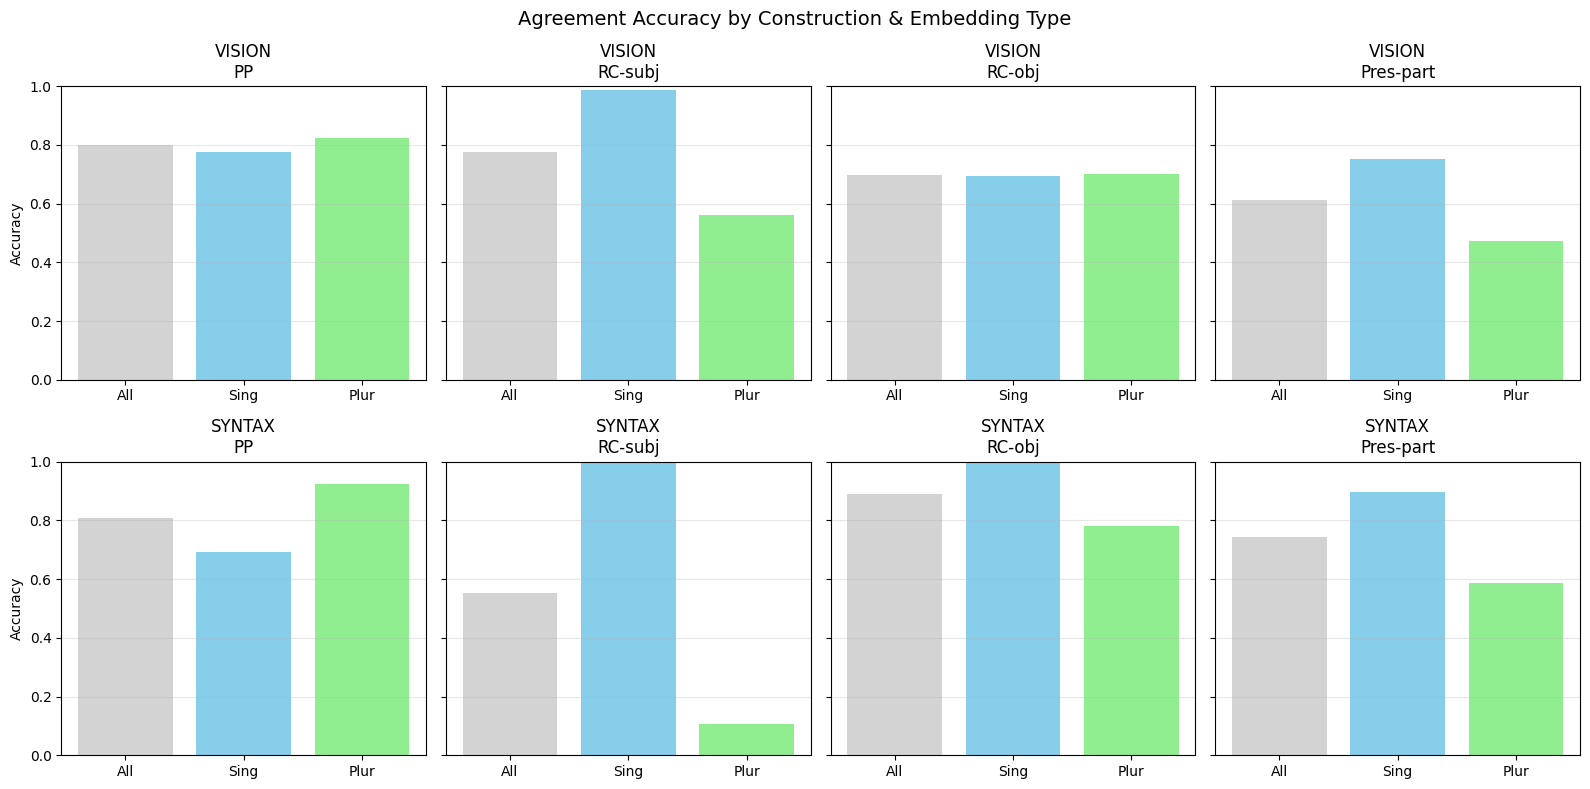


SUMMARY
Construction   Metric         Vision     Syntax       Diff
------------------------------------------------------
PP             overall         0.798      0.807     -0.009
PP             singular        0.775      0.691     +0.084
PP             plural          0.822      0.924     -0.102
------------------------------------------------------
RC-subj        overall         0.774      0.554     +0.221
RC-subj        singular        0.987      1.000     -0.013
RC-subj        plural          0.562      0.108     +0.455
------------------------------------------------------
RC-obj         overall         0.697      0.888     -0.192
RC-obj         singular        0.693      0.997     -0.303
RC-obj         plural          0.700      0.780     -0.080
------------------------------------------------------
Pres-part      overall         0.611      0.742     -0.131
Pres-part      singular        0.752      0.897     -0.145
Pres-part      plural          0.471      0.587     -0.116
----

In [11]:
import torch
import matplotlib.pyplot as plt

# ==========================================================
# 0. Add tokens ONCE
# ==========================================================
added_tokens = [" [wug]", " [wugs]"]
existing_vocab = lm.tokenizer.tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    lm.tokenizer.tokenizer.add_tokens(tokens_to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(tokens_to_add))
    print(f"Added tokens: {tokens_to_add}")
else:
    print("Tokens already in vocab")

# ==========================================================
# 1. Construction sets
# ==========================================================

construction_sets = {
    "PP": pp_pairs,
    "RC-subj": rc_subj_pairs,
    "RC-obj": rc_obj_pairs,
    "Pres-part": pres_part_pairs,
}

# ==========================================================
# 2. Build good/bad pairs — contrast is wug vs wugs, NOT is vs are
# ==========================================================

def build_goods_bads(pairs):
    goods = []
    bads = []
    for p in pairs:
        # "is" context: singular [wug] is correct
        goods.append(p["singular"] + " is")
        bads.append(p["plural"] + " is")
        # "are" context: plural [wugs] is correct
        goods.append(p["plural"] + " are")
        bads.append(p["singular"] + " are")
    return goods, bads

# Debug: verify
for cname, pairs in construction_sets.items():
    goods, bads = build_goods_bads(pairs)
    print(f"\n{cname}:")
    print(f"  Good[0]: {goods[0]}")
    print(f"  Bad[0]:  {bads[0]}")
    print(f"  Good[1]: {goods[1]}")
    print(f"  Bad[1]:  {bads[1]}")
    break

# ==========================================================
# 3. Run eval for each embedding × construction
# ==========================================================

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"
all_results = {}

for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\n{'='*60}")
    print(f"Condition: {condition.upper()}")
    print(f"{'='*60}")
    
    saved = torch.load(embed_path)
    emb = lm.model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    
    print(f"  Loaded {condition} embeddings")
    print(f"    [wug]  norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
    print(f"    [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")
    
    all_results[condition] = {}
    
    for cname, pairs in construction_sets.items():
        goods, bads = build_goods_bads(pairs)
        
        good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
        bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]
        
        good_scores = lm.sequence_score(good_queries)
        bad_scores  = lm.sequence_score(bad_queries)
        
        diffs = torch.tensor(good_scores) - torch.tensor(bad_scores)
        acc_mask = (diffs > 0).float()
        
        # Even indices: "is" context (singular should win)
        # Odd indices: "are" context (plural should win)
        sing_idx = list(range(0, len(goods), 2))
        plur_idx = list(range(1, len(goods), 2))
        
        overall_acc = acc_mask.mean().item()
        sing_acc = acc_mask[sing_idx].mean().item()
        plur_acc = acc_mask[plur_idx].mean().item()
        
        print(f"\n  {cname} ({len(pairs)} pairs):")
        print(f"    Singular ([wug]+is > [wugs]+is):     {sing_acc:.3f}")
        print(f"    Plural   ([wugs]+are > [wug]+are):   {plur_acc:.3f}")
        print(f"    Overall:                             {overall_acc:.3f}")
        
        all_results[condition][cname] = {
            "overall": overall_acc,
            "singular": sing_acc,
            "plural": plur_acc,
        }

# ==========================================================
# 4. Plot
# ==========================================================

cnames = list(construction_sets.keys())
fig, axes = plt.subplots(2, len(cnames), figsize=(4 * len(cnames), 8), sharey=True)

for row, condition in enumerate(["vision", "syntax"]):
    for col, cname in enumerate(cnames):
        ax = axes[row][col]
        r = all_results[condition][cname]
        ax.bar(["All", "Sing", "Plur"],
               [r["overall"], r["singular"], r["plural"]],
               color=["lightgray", "skyblue", "lightgreen"])
        ax.set_ylim(0, 1)
        ax.set_title(f"{condition.upper()}\n{cname}")
        ax.grid(axis="y", alpha=0.3)
        if col == 0:
            ax.set_ylabel("Accuracy")

plt.suptitle("Agreement Accuracy by Construction & Embedding Type", fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================================
# 5. Summary table
# ==========================================================

print(f"\n{'='*70}")
print(f"SUMMARY")
print(f"{'='*70}")
print(f"{'Construction':<14} {'Metric':<10} {'Vision':>10} {'Syntax':>10} {'Diff':>10}")
print(f"{'-'*54}")
for cname in cnames:
    for metric in ["overall", "singular", "plural"]:
        v = all_results["vision"][cname][metric]
        s = all_results["syntax"][cname][metric]
        d = v - s
        print(f"{cname:<14} {metric:<10} {v:>10.3f} {s:>10.3f} {d:>+10.3f}")
    print(f"{'-'*54}")

In [12]:
import torch
import random

# ==========================================================
# 0. Setup
# ==========================================================
model = lm.model
tokenizer = lm.tokenizer.tokenizer
device = "cuda"

added_tokens = [" [wug]", " [wugs]"]
existing_vocab = tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    tokenizer.add_tokens(tokens_to_add)
    old_len = model.resize_token_embeddings().weight.shape[0]
    model.resize_token_embeddings(old_len + len(tokens_to_add))
    print(f"Added tokens: {tokens_to_add}")
else:
    print("Tokens already in vocab")

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"

# ==========================================================
# 1. Build natural pairs
# ==========================================================

def make_natural_pairs(wug_pairs):
    nat = []
    for p in wug_pairs:
        nat.append({
            "singular": p["singular"].replace("[wug]", "dog"),
            "plural": p["plural"].replace("[wugs]", "dogs"),
        })
    return nat

natural_rc_obj = make_natural_pairs(rc_obj_pairs)

# ==========================================================
# 2. Check each pair — matching document 39 format exactly
#    Good: singular + " is" vs Bad: plural + " is"
#    Good: plural + " are" vs Bad: singular + " are"
# ==========================================================

def check_pair(pair, lm):
    """Check if model gets both singular and plural correct for one pair."""
    # Singular: does singular+is beat plural+is?
    g1 = chat_template(lm, pair["singular"] + " is", noimage=True, assistant=False)
    b1 = chat_template(lm, pair["plural"] + " is", noimage=True, assistant=False)
    s1 = lm.sequence_score([g1, b1])
    sing_ok = s1[0] > s1[1]
    
    # Plural: does plural+are beat singular+are?
    g2 = chat_template(lm, pair["plural"] + " are", noimage=True, assistant=False)
    b2 = chat_template(lm, pair["singular"] + " are", noimage=True, assistant=False)
    s2 = lm.sequence_score([g2, b2])
    plur_ok = s2[0] > s2[1]
    
    return sing_ok and plur_ok

# Check natural (dog/dogs)
print("Checking natural (dog/dogs)...")
nat_correct = [check_pair(p, lm) for p in natural_rc_obj]
print(f"  Correct: {sum(nat_correct)}/{len(nat_correct)}")

# Check each embedding condition
condition_correct = {}
for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\nChecking {condition}...")
    saved = torch.load(embed_path)
    emb = model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    
    correct = [check_pair(p, lm) for p in rc_obj_pairs]
    condition_correct[condition] = correct
    print(f"  Correct: {sum(correct)}/{len(correct)}")

# ==========================================================
# 3. Filter to pairs ALL conditions get right
# ==========================================================

all_correct_mask = []
for i in range(len(rc_obj_pairs)):
    ok = nat_correct[i] and condition_correct["vision"][i] and condition_correct["syntax"][i]
    all_correct_mask.append(ok)

filtered_wug_pairs = [p for p, ok in zip(rc_obj_pairs, all_correct_mask) if ok]
filtered_nat_pairs = [p for p, ok in zip(natural_rc_obj, all_correct_mask) if ok]

print(f"\n{'='*50}")
print(f"Pairs correct under ALL conditions: {len(filtered_wug_pairs)} / {len(rc_obj_pairs)}")
print(f"{'='*50}")

print("\nSample filtered pairs:")
for p in filtered_wug_pairs[:5]:
    print(f"  Wug: {p['singular']} / {p['plural']}")
for p in filtered_nat_pairs[:5]:
    print(f"  Nat: {p['singular']} / {p['plural']}")

Tokens already in vocab
Checking natural (dog/dogs)...
  Correct: 300/300

Checking vision...
  Correct: 132/300

Checking syntax...
  Correct: 234/300

Pairs correct under ALL conditions: 118 / 300

Sample filtered pairs:
  Wug: The [wug] he caught / The [wugs] he caught
  Wug: The [wug] he bit / The [wugs] he bit
  Wug: The [wug] he touched / The [wugs] he touched
  Wug: The [wug] he grabbed / The [wugs] he grabbed
  Wug: The [wug] he threw / The [wugs] he threw
  Nat: The dog he caught / The dogs he caught
  Nat: The dog he bit / The dogs he bit
  Nat: The dog he touched / The dogs he touched
  Nat: The dog he grabbed / The dogs he grabbed
  Nat: The dog he threw / The dogs he threw


In [13]:
import pyvene as pv
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
import json
import os

# ==========================================================
# 0. Setup
# ==========================================================
model = lm.model
tokenizer = lm.tokenizer.tokenizer
hidden_size = model.language_model.config.hidden_size
device = "cuda"
num_layers = model.language_model.config.num_hidden_layers

added_tokens = [" [wug]", " [wugs]"]
existing_vocab = tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    tokenizer.add_tokens(tokens_to_add)
    old_len = model.resize_token_embeddings().weight.shape[0]
    model.resize_token_embeddings(old_len + len(tokens_to_add))
    print(f"Added tokens: {tokens_to_add}")
else:
    print("Tokens already in vocab")

is_id = tokenizer.encode(" is", add_special_tokens=False)[0]
are_id = tokenizer.encode(" are", add_special_tokens=False)[0]
print(f"is: {is_id}, are: {are_id}")

sample = "The [wug] he saw"
toks = [tokenizer.decode([t]) for t in tokenizer.encode(sample)]
print(f"\nToken positions: {list(enumerate(toks))}")
position_names = {0: "The", 1: "noun", 2: "pron", 3: "verb"}

# ==========================================================
# 1. Build natural eval pairs for multiple animals
# ==========================================================

animal_pairs = {
    "dog/dogs": ("dog", "dogs"),
    "cat/cats": ("cat", "cats"),
    "bird/birds": ("bird", "birds"),
    "horse/horses": ("horse", "horses"),
    "fish/fish": ("fish", "fish"),
    "rat/rats": ("rat", "rats"),
}

print("\nAnimal tokenization check:")
for label, (sing, plur) in animal_pairs.items():
    s_toks = tokenizer.encode(f" {sing}", add_special_tokens=False)
    p_toks = tokenizer.encode(f" {plur}", add_special_tokens=False)
    ok = len(s_toks) == 1 and len(p_toks) == 1
    print(f"  {label}: sing={len(s_toks)} plur={len(p_toks)} {'OK' if ok else 'MULTI-TOKEN!'}")

def make_natural_pairs(wug_pairs, sing_word, plur_word):
    nat = []
    for p in wug_pairs:
        nat.append({
            "singular": p["singular"].replace("[wug]", sing_word),
            "plural": p["plural"].replace("[wugs]", plur_word),
        })
    return nat

print(f"\nUsing ALL filtered pairs for training: {len(filtered_wug_pairs)}")

# ==========================================================
# 2. Tokenize
# ==========================================================

def tokenize_pair(singular_text, plural_text, tokenizer, device):
    src = tokenizer(plural_text, return_tensors="pt").to(device)
    base = tokenizer(singular_text, return_tensors="pt").to(device)
    return {
        "src": src, "base": base,
        "src_len": src.input_ids.shape[1],
        "base_len": base.input_ids.shape[1],
    }

# ==========================================================
# 3. DAS functions
# ==========================================================

def train_das_layer_pos(model, train_pairs_tok, layer_i, intervene_pos,
                        hidden_size, device, n_steps=200, lr=5e-3):
    rotate_layer = nn.Linear(hidden_size, 1, bias=False)
    nn.init.orthogonal_(rotate_layer.weight)
    rotate_layer = rotate_layer.to(device=device, dtype=torch.bfloat16)
    
    def das_fn(b, s):
        w = rotate_layer.weight
        a = (w / w.norm()).squeeze(0)
        bp = (b * a).sum(-1, keepdim=True)
        sp = (s * a).sum(-1, keepdim=True)
        return b + (sp - bp) * a
    
    pv_das = pv.IntervenableModel({
        "component": f"model.language_model.layers[{layer_i}].output",
        "intervention": das_fn,
    }, model=model)
    
    optimizer = torch.optim.Adam(rotate_layer.parameters(), lr=lr)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * n_steps), num_training_steps=n_steps
    )
    
    for param in model.parameters():
        param.requires_grad = False
    
    predict_pos = train_pairs_tok[0]["base_len"] - 1
    
    for step in range(n_steps):
        pair = train_pairs_tok[step % len(train_pairs_tok)]
        
        _, out = pv_das(
            pair["base"], [pair["src"]],
            {"sources->base": ([[[intervene_pos]]], [[[intervene_pos]]])},
        )
        
        logits = out.logits[:, predict_pos, :]
        target = torch.tensor([are_id], device=device)
        loss = F.cross_entropy(logits.float(), target)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    
    del pv_das
    return rotate_layer


def compute_odds_layer_pos(model, eval_pairs_tok, rotate_layer, 
                           layer_i, intervene_pos, device, is_id, are_id):
    def das_fn(b, s):
        w = rotate_layer.weight
        a = (w / w.norm()).squeeze(0)
        bp = (b * a).sum(-1, keepdim=True)
        sp = (s * a).sum(-1, keepdim=True)
        return b + (sp - bp) * a
    
    pv_das = pv.IntervenableModel({
        "component": f"model.language_model.layers[{layer_i}].output",
        "intervention": das_fn,
    }, model=model)
    
    predict_pos = eval_pairs_tok[0]["base_len"] - 1
    
    odds_list = []
    with torch.no_grad():
        for pair in eval_pairs_tok:
            _, out = pv_das(
                pair["base"], [pair["src"]],
                {"sources->base": ([[[intervene_pos]]], [[[intervene_pos]]])},
            )
            
            probs = torch.softmax(out.logits[:, predict_pos, :].float(), dim=-1)
            p_are = probs[0, are_id].item()
            p_is = probs[0, is_id].item()
            
            if p_is > 1e-10:
                odds_list.append(p_are / p_is)
    
    del pv_das
    return sum(odds_list) / len(odds_list) if odds_list else 0.0

# ==========================================================
# 4. Run DAS
# ==========================================================

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"

layers_to_test = [35]
positions_to_test = [0,1,2,3]

print(f"Layers: {layers_to_test}")
print(f"Positions: {[position_names[p] for p in positions_to_test]}")

RESULTS_FILE = "das_rc_obj_full_results.json"

# Load existing results if resuming
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        save_data = json.load(f)
    all_das_results = save_data.get("results", {})
    print(f"\nLoaded existing results from {RESULTS_FILE}")
else:
    all_das_results = {}

for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\n{'='*60}")
    print(f"DAS Condition: {condition.upper()}")
    print(f"{'='*60}")
    
    saved = torch.load(embed_path)
    emb = model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    print(f"  [wug] norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
    print(f"  [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")
    
    wug_train_tok = [tokenize_pair(p["singular"], p["plural"], tokenizer, device) for p in filtered_wug_pairs]
    
    nat_eval_sets = {}
    for animal_label, (sing, plur) in animal_pairs.items():
        nat_pairs = make_natural_pairs(filtered_wug_pairs, sing, plur)
        nat_eval_sets[animal_label] = [tokenize_pair(p["singular"], p["plural"], tokenizer, device) for p in nat_pairs]
    
    print(f"  Train (wug): {len(wug_train_tok)}")
    
    if condition not in all_das_results:
        all_das_results[condition] = []
    
    for pos_i in positions_to_test:
        # Check if this position is already done
        done_layers = [r["layer"] for r in all_das_results[condition] if r["position"] == pos_i]
        if set(layers_to_test).issubset(set(done_layers)):
            print(f"\n  Position {position_names[pos_i]}: already done, skipping")
            continue
        
        for layer_i in layers_to_test:
            if layer_i in done_layers:
                print(f"  pos={position_names[pos_i]:5s} layer={layer_i:2d}: already done, skipping")
                continue
            
            print(f"  pos={position_names[pos_i]:5s} layer={layer_i:2d}:", end=" ")
            
            rotate_layer = train_das_layer_pos(
                model, wug_train_tok, layer_i, pos_i,
                hidden_size, device, n_steps=200, lr=5e-3
            )
            
            odds_wug = compute_odds_layer_pos(
                model, wug_train_tok, rotate_layer,
                layer_i, pos_i, device, is_id, are_id
            )
            
            animal_odds = {}
            for animal_label, nat_tok in nat_eval_sets.items():
                animal_odds[animal_label] = compute_odds_layer_pos(
                    model, nat_tok, rotate_layer,
                    layer_i, pos_i, device, is_id, are_id
                )
            
            mean_nat = sum(animal_odds.values()) / len(animal_odds)
            
            print(f"wug={odds_wug:.4f}, mean_nat={mean_nat:.4f} " + 
                  " ".join(f"{k.split('/')[0]}={v:.4f}" for k, v in animal_odds.items()))
            
            all_das_results[condition].append({
                "position": pos_i,
                "position_name": position_names[pos_i],
                "layer": layer_i,
                "odds_wug": odds_wug,
                "mean_natural": mean_nat,
                **{f"odds_{k}": v for k, v in animal_odds.items()},
            })
            
            torch.cuda.empty_cache()
        
        # Save after each position completes
        save_data = {
            "filtered_count": len(filtered_wug_pairs),
            "layers": layers_to_test,
            "positions": positions_to_test,
            "position_names": {str(k): v for k, v in position_names.items()},
            "animals": list(animal_pairs.keys()),
            "results": all_das_results,
        }
        with open(RESULTS_FILE, "w") as f:
            json.dump(save_data, f, indent=2)
        print(f"  -> Saved checkpoint to {RESULTS_FILE}")

# ==========================================================
# 5. Final save
# ==========================================================

save_data = {
    "filtered_count": len(filtered_wug_pairs),
    "layers": layers_to_test,
    "positions": positions_to_test,
    "position_names": {str(k): v for k, v in position_names.items()},
    "animals": list(animal_pairs.keys()),
    "results": all_das_results,
}
with open(RESULTS_FILE, "w") as f:
    json.dump(save_data, f, indent=2)
print(f"\nFinal save to {RESULTS_FILE}")


Tokens already in vocab
is: 374, are: 525

Token positions: [(0, 'The'), (1, ' [wug]'), (2, ' he'), (3, ' saw')]

Animal tokenization check:
  dog/dogs: sing=1 plur=1 OK
  cat/cats: sing=1 plur=1 OK
  bird/birds: sing=1 plur=1 OK
  horse/horses: sing=1 plur=1 OK
  fish/fish: sing=1 plur=1 OK
  rat/rats: sing=1 plur=1 OK

Using ALL filtered pairs for training: 118
Layers: [35]
Positions: ['The', 'noun', 'pron', 'verb']

Loaded existing results from das_rc_obj_full_results.json

DAS Condition: VISION
  [wug] norm: 1.0781
  [wugs] norm: 1.0781
  Train (wug): 118

  Position The: already done, skipping

  Position noun: already done, skipping

  Position pron: already done, skipping

  Position verb: already done, skipping

DAS Condition: SYNTAX
  [wug] norm: 1.3906
  [wugs] norm: 1.3203
  Train (wug): 118

  Position The: already done, skipping

  Position noun: already done, skipping

  Position pron: already done, skipping

  Position verb: already done, skipping

Final save to das_rc_o

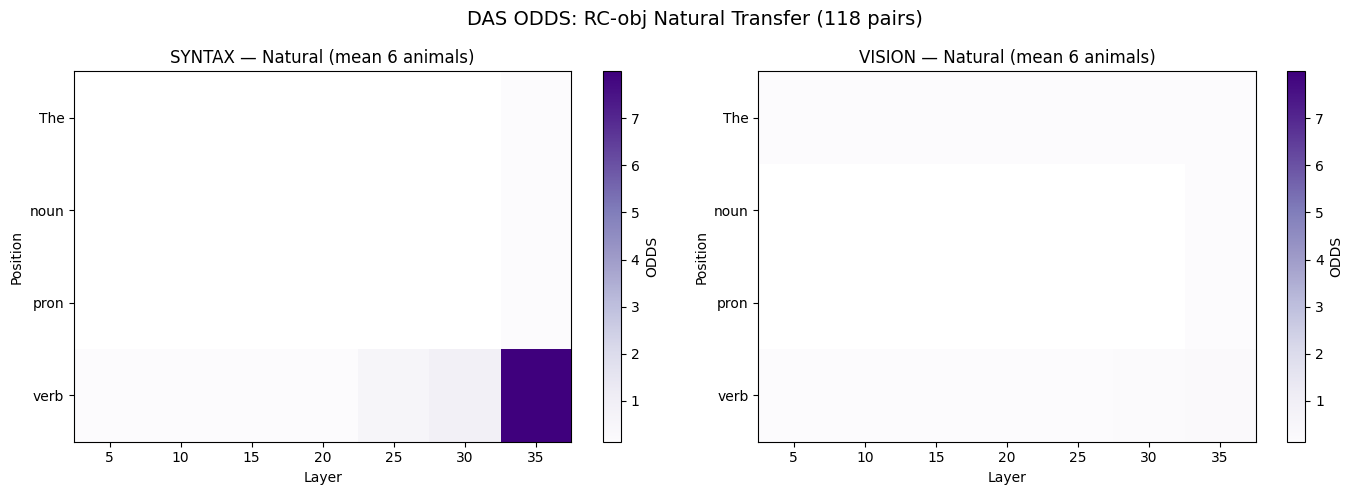

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import json

with open("das_rc_obj_full_results.json", "r") as f:
    save_data = json.load(f)

all_das_results = save_data["results"]
position_names = {int(k): v for k, v in save_data["position_names"].items()}

all_layers = sorted(set(r["layer"] for cond in all_das_results.values() for r in cond))
all_positions = sorted(set(r["position"] for cond in all_das_results.values() for r in cond))

def build_heatmap(results, metric, positions, layers):
    heatmap = np.full((len(positions), len(layers)), np.nan)
    for r in results:
        if r["position"] in positions and r["layer"] in layers:
            pi = positions.index(r["position"])
            li = layers.index(r["layer"])
            heatmap[pi, li] = r[metric]
    return heatmap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shared color scale
h_syntax = build_heatmap(all_das_results["syntax"], "mean_natural", all_positions, all_layers)
h_vision = build_heatmap(all_das_results["vision"], "mean_natural", all_positions, all_layers)
vmin = np.nanmin([np.nanmin(h_syntax), np.nanmin(h_vision)])
vmax = np.nanmax([np.nanmax(h_syntax), np.nanmax(h_vision)])

for col, (condition, heatmap) in enumerate([("syntax", h_syntax), ("vision", h_vision)]):
    ax = axes[col]
    im = ax.imshow(heatmap, aspect="auto", cmap="Purples", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(all_layers)))
    ax.set_xticklabels(all_layers)
    ax.set_yticks(range(len(all_positions)))
    ax.set_yticklabels([position_names[p] for p in all_positions])
    ax.set_xlabel("Layer")
    ax.set_ylabel("Position")
    ax.set_title(f"{condition.upper()} — Natural (mean 6 animals)")
    plt.colorbar(im, ax=ax, label="ODDS")

plt.suptitle(f"DAS ODDS: RC-obj Natural Transfer ({save_data['filtered_count']} pairs)", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# ==========================================================
# 4. Run DAS (train on animals, test on wug)
# ==========================================================

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"

layers_to_test = [5, 35]
positions_to_test = [0, 1, 2, 3]
animal_pairs = {
    "dog/dogs": ("dog", "dogs"),
    "cat/cats": ("cat", "cats"),
    "bird/birds": ("bird", "birds"),
    "horse/horses": ("horse", "horses"),
    "fish/fish": ("fish", "fish"),
    "rat/rats": ("rat", "rats"),
}
print(f"Layers: {layers_to_test}")
print(f"Positions: {[position_names[p] for p in positions_to_test]}")

RESULTS_FILE = "das_rc_obj_nat2wug_results_rev.json"

# Load existing results if resuming
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        save_data = json.load(f)
    all_das_results = save_data.get("results", {})
    print(f"\nLoaded existing results from {RESULTS_FILE}")
else:
    all_das_results = {}

for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\n{'='*60}")
    print(f"DAS Condition: {condition.upper()} (train=animals, test=wug)")
    print(f"{'='*60}")

    saved = torch.load(embed_path)
    emb = model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    print(f"  [wug] norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
    print(f"  [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")

    # Build animal TRAINING set (pool all animals together)
    nat_train_tok = []
    for animal_label, (sing, plur) in animal_pairs.items():
        nat_pairs = make_natural_pairs(filtered_wug_pairs, sing, plur)
        nat_train_tok.extend([tokenize_pair(p["singular"], p["plural"], tokenizer, device) for p in nat_pairs])

    # Build wug EVAL set
    wug_eval_tok = [tokenize_pair(p["singular"], p["plural"], tokenizer, device) for p in filtered_wug_pairs]

    # Also keep per-animal eval for breakdown
    nat_eval_sets = {}
    for animal_label, (sing, plur) in animal_pairs.items():
        nat_pairs = make_natural_pairs(filtered_wug_pairs, sing, plur)
        nat_eval_sets[animal_label] = [tokenize_pair(p["singular"], p["plural"], tokenizer, device) for p in nat_pairs]

    print(f"  Train (animals pooled): {len(nat_train_tok)}")
    print(f"  Eval (wug): {len(wug_eval_tok)}")

    if condition not in all_das_results:
        all_das_results[condition] = []

    for pos_i in positions_to_test:
        done_layers = [r["layer"] for r in all_das_results[condition] if r["position"] == pos_i]
        if set(layers_to_test).issubset(set(done_layers)):
            print(f"\n  Position {position_names[pos_i]}: already done, skipping")
            continue

        for layer_i in layers_to_test:
            if layer_i in done_layers:
                print(f"  pos={position_names[pos_i]:5s} layer={layer_i:2d}: already done, skipping")
                continue

            print(f"  pos={position_names[pos_i]:5s} layer={layer_i:2d}:", end=" ")

            # TRAIN on animals
            rotate_layer = train_das_layer_pos(
                model, nat_train_tok, layer_i, pos_i,
                hidden_size, device, n_steps=200, lr=5e-3
            )

            # TEST on wug
            odds_wug = compute_odds_layer_pos(
                model, wug_eval_tok, rotate_layer,
                layer_i, pos_i, device, is_id, are_id
            )

            # Also eval on each animal (train dist)
            animal_odds = {}
            for animal_label, nat_tok in nat_eval_sets.items():
                animal_odds[animal_label] = compute_odds_layer_pos(
                    model, nat_tok, rotate_layer,
                    layer_i, pos_i, device, is_id, are_id
                )

            mean_nat = sum(animal_odds.values()) / len(animal_odds)

            print(f"wug={odds_wug:.4f}, mean_nat={mean_nat:.4f} " +
                  " ".join(f"{k.split('/')[0]}={v:.4f}" for k, v in animal_odds.items()))

            all_das_results[condition].append({
                "position": pos_i,
                "position_name": position_names[pos_i],
                "layer": layer_i,
                "odds_wug": odds_wug,
                "mean_natural": mean_nat,
                **{f"odds_{k}": v for k, v in animal_odds.items()},
            })

            torch.cuda.empty_cache()

        # Save after each position completes
        save_data = {
            "filtered_count": len(filtered_wug_pairs),
            "layers": layers_to_test,
            "positions": positions_to_test,
            "position_names": {str(k): v for k, v in position_names.items()},
            "animals": list(animal_pairs.keys()),
            "direction": "train=animals, test=wug",
            "results": all_das_results,
        }
        with open(RESULTS_FILE, "w") as f:
            json.dump(save_data, f, indent=2)
        print(f"  -> Saved checkpoint to {RESULTS_FILE}")

# ==========================================================
# 5. Final save
# ==========================================================

save_data = {
    "filtered_count": len(filtered_wug_pairs),
    "layers": layers_to_test,
    "positions": positions_to_test,
    "position_names": {str(k): v for k, v in position_names.items()},
    "animals": list(animal_pairs.keys()),
    "direction": "train=animals, test=wug",
    "results": all_das_results,
}
with open(RESULTS_FILE, "w") as f:
    json.dump(save_data, f, indent=2)
print(f"\nFinal save to {RESULTS_FILE}")

Layers: [5, 35]
Positions: ['The', 'noun', 'pron', 'verb']

Loaded existing results from das_rc_obj_nat2wug_results_rev.json

DAS Condition: VISION (train=animals, test=wug)
  [wug] norm: 1.0781
  [wugs] norm: 1.0781
  Train (animals pooled): 708
  Eval (wug): 118

  Position The: already done, skipping

  Position noun: already done, skipping

  Position pron: already done, skipping

  Position verb: already done, skipping

DAS Condition: SYNTAX (train=animals, test=wug)
  [wug] norm: 1.3906
  [wugs] norm: 1.3203
  Train (animals pooled): 708
  Eval (wug): 118

  Position The: already done, skipping

  Position noun: already done, skipping

  Position pron: already done, skipping

  Position verb: already done, skipping

Final save to das_rc_obj_nat2wug_results_rev.json


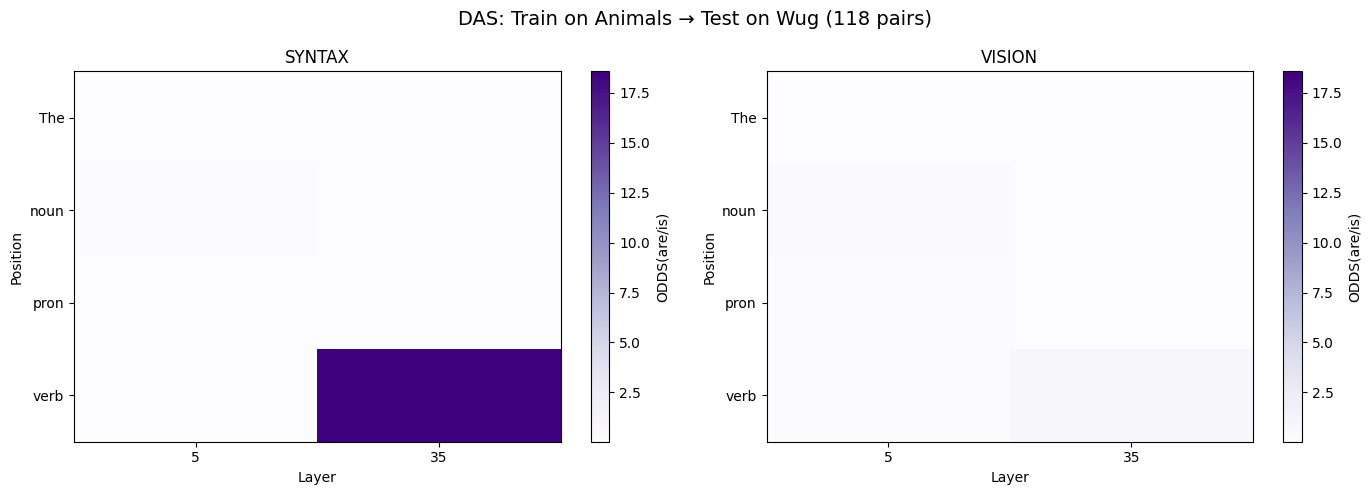

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import json

with open("das_rc_obj_nat2wug_results_rev.json", "r") as f:
    save_data = json.load(f)

all_das_results = save_data["results"]
position_names = {int(k): v for k, v in save_data["position_names"].items()}

all_layers = sorted(set(r["layer"] for cond in all_das_results.values() for r in cond))
all_positions = sorted(set(r["position"] for cond in all_das_results.values() for r in cond))

def build_heatmap(results, metric, positions, layers):
    heatmap = np.full((len(positions), len(layers)), np.nan)
    for r in results:
        if r["position"] in positions and r["layer"] in layers:
            pi = positions.index(r["position"])
            li = layers.index(r["layer"])
            heatmap[pi, li] = r[metric]
    return heatmap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h_syntax = build_heatmap(all_das_results["syntax"], "odds_wug", all_positions, all_layers)
h_vision = build_heatmap(all_das_results["vision"], "odds_wug", all_positions, all_layers)
vmin = np.nanmin([np.nanmin(h_syntax), np.nanmin(h_vision)])
vmax = np.nanmax([np.nanmax(h_syntax), np.nanmax(h_vision)])

for col, (condition, heatmap) in enumerate([("syntax", h_syntax), ("vision", h_vision)]):
    ax = axes[col]
    im = ax.imshow(heatmap, aspect="auto", cmap="Purples", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(all_layers)))
    ax.set_xticklabels(all_layers)
    ax.set_yticks(range(len(all_positions)))
    ax.set_yticklabels([position_names[p] for p in all_positions])
    ax.set_xlabel("Layer")
    ax.set_ylabel("Position")
    ax.set_title(f"{condition.upper()}")
    plt.colorbar(im, ax=ax, label="ODDS(are/is)")

plt.suptitle(f"DAS: Train on Animals → Test on Wug ({save_data['filtered_count']} pairs)", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
import pyvene as pv
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
import os
import numpy as np

# ==========================================================
# 0. Setup
# ==========================================================
model = lm.model
tokenizer = lm.tokenizer.tokenizer
hidden_size = model.language_model.config.hidden_size
device = "cuda"
num_layers = model.language_model.config.num_hidden_layers

added_tokens = [" [wug]", " [wugs]"]
existing_vocab = tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    tokenizer.add_tokens(tokens_to_add)
    old_len = model.resize_token_embeddings().weight.shape[0]
    model.resize_token_embeddings(old_len + len(tokens_to_add))
    print(f"Added tokens: {tokens_to_add}")
else:
    print("Tokens already in vocab")

is_id = tokenizer.encode(" is", add_special_tokens=False)[0]
are_id = tokenizer.encode(" are", add_special_tokens=False)[0]
print(f"is: {is_id}, are: {are_id}")

sample = "The [wug] he saw"
toks = [tokenizer.decode([t]) for t in tokenizer.encode(sample)]
print(f"\nToken positions: {list(enumerate(toks))}")
position_names = {0: "The", 1: "noun", 2: "pron", 3: "verb"}

# ==========================================================
# 1. Build natural eval pairs for multiple animals
# ==========================================================

animal_pairs = {
    "dog/dogs": ("dog", "dogs"),
    "cat/cats": ("cat", "cats"),
    "bird/birds": ("bird", "birds"),
    "horse/horses": ("horse", "horses"),
    "fish/fish": ("fish", "fish"),
    "rat/rats": ("rat", "rats"),
}

print("\nAnimal tokenization check:")
for label, (sing, plur) in animal_pairs.items():
    s_toks = tokenizer.encode(f" {sing}", add_special_tokens=False)
    p_toks = tokenizer.encode(f" {plur}", add_special_tokens=False)
    ok = len(s_toks) == 1 and len(p_toks) == 1
    print(f"  {label}: sing={len(s_toks)} plur={len(p_toks)} {'OK' if ok else 'MULTI-TOKEN!'}")

def make_natural_pairs(wug_pairs, sing_word, plur_word):
    nat = []
    for p in wug_pairs:
        nat.append({
            "singular": p["singular"].replace("[wug]", sing_word),
            "plural": p["plural"].replace("[wugs]", plur_word),
        })
    return nat

print(f"\nUsing ALL filtered pairs for training/eval: {len(filtered_wug_pairs)}")

# ==========================================================
# 2. Tokenize
# ==========================================================

def tokenize_pair(singular_text, plural_text, tokenizer, device):
    src = tokenizer(plural_text, return_tensors="pt").to(device)
    base = tokenizer(singular_text, return_tensors="pt").to(device)
    return {
        "src": src, "base": base,
        "src_len": src.input_ids.shape[1],
        "base_len": base.input_ids.shape[1],
    }

# ==========================================================
# 3. Diffmean: collect activations and compute direction
# ==========================================================

def collect_activations(model, pairs_tok, layer_i, pos_i, device):
    """Run forward pass on singular and plural inputs,
    collect residual-stream activations at (layer_i, pos_i)."""
    singular_acts = []
    plural_acts = []

    hooks = []
    captured = {}

    def make_hook(name):
        def hook_fn(module, input, output):
            # output is a tuple; first element is the hidden state
            if isinstance(output, tuple):
                captured[name] = output[0].detach()
            else:
                captured[name] = output.detach()
        return hook_fn

    target_module = model.language_model.layers[layer_i]
    hook = target_module.register_forward_hook(make_hook("act"))
    hooks.append(hook)

    with torch.no_grad():
        for pair in pairs_tok:
            # Singular (base)
            captured.clear()
            model(**pair["base"])
            singular_acts.append(captured["act"][0, pos_i].float().cpu())

            # Plural (source)
            captured.clear()
            model(**pair["src"])
            plural_acts.append(captured["act"][0, pos_i].float().cpu())

    for h in hooks:
        h.remove()

    return torch.stack(singular_acts), torch.stack(plural_acts)


def compute_diffmean_direction(singular_acts, plural_acts):
    """Compute the unit diffmean direction: mean(plural) - mean(singular), normalized."""
    diff = plural_acts.mean(dim=0) - singular_acts.mean(dim=0)
    direction = diff / diff.norm()
    return direction

# ==========================================================
# 4. Diffmean intervention + eval
# ==========================================================

def compute_odds_diffmean(model, eval_pairs_tok, direction,
                          layer_i, intervene_pos, device, is_id, are_id):
    """
    For each pair, run singular (base) with diffmean intervention at
    (layer_i, intervene_pos): swap the component along `direction`
    from the singular activation to the plural activation's projection.
    
    This is equivalent to: h_new = h_base + ((h_src · d) - (h_base · d)) * d
    but we do it via pyvene for consistency.
    """
    direction_dev = direction.to(device=device, dtype=torch.bfloat16)

    def diffmean_fn(b, s):
        d = direction_dev
        bp = (b * d).sum(-1, keepdim=True)
        sp = (s * d).sum(-1, keepdim=True)
        return b + (sp - bp) * d

    pv_model = pv.IntervenableModel({
        "component": f"model.language_model.layers[{layer_i}].output",
        "intervention": diffmean_fn,
    }, model=model)

    predict_pos = eval_pairs_tok[0]["base_len"] - 1

    odds_list = []
    with torch.no_grad():
        for pair in eval_pairs_tok:
            _, out = pv_model(
                pair["base"], [pair["src"]],
                {"sources->base": ([[[intervene_pos]]], [[[intervene_pos]]])},
            )

            probs = torch.softmax(out.logits[:, predict_pos, :].float(), dim=-1)
            p_are = probs[0, are_id].item()
            p_is = probs[0, is_id].item()

            if p_is > 1e-10:
                odds_list.append(p_are / p_is)

    del pv_model
    return sum(odds_list) / len(odds_list) if odds_list else 0.0

# ==========================================================
# 5. Run diffmean intervention
# ==========================================================

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"

layers_to_test = [35]
positions_to_test = [0, 1, 2, 3]

print(f"Layers: {layers_to_test}")
print(f"Positions: {[position_names[p] for p in positions_to_test]}")

RESULTS_FILE = "diffmean_rc_obj_full_results.json"

# Load existing results if resuming
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        save_data = json.load(f)
    all_results = save_data.get("results", {})
    print(f"\nLoaded existing results from {RESULTS_FILE}")
else:
    all_results = {}

for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\n{'='*60}")
    print(f"Diffmean Condition: {condition.upper()}")
    print(f"{'='*60}")

    saved = torch.load(embed_path)
    emb = model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    print(f"  [wug] norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
    print(f"  [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")

    wug_train_tok = [tokenize_pair(p["singular"], p["plural"], tokenizer, device) for p in filtered_wug_pairs]

    nat_eval_sets = {}
    for animal_label, (sing, plur) in animal_pairs.items():
        nat_pairs = make_natural_pairs(filtered_wug_pairs, sing, plur)
        nat_eval_sets[animal_label] = [tokenize_pair(p["singular"], p["plural"], tokenizer, device) for p in nat_pairs]

    print(f"  Train/eval (wug): {len(wug_train_tok)}")

    if condition not in all_results:
        all_results[condition] = []

    for pos_i in positions_to_test:
        # Check if this position is already done
        done_layers = [r["layer"] for r in all_results[condition] if r["position"] == pos_i]
        if set(layers_to_test).issubset(set(done_layers)):
            print(f"\n  Position {position_names[pos_i]}: already done, skipping")
            continue

        for layer_i in layers_to_test:
            if layer_i in done_layers:
                print(f"  pos={position_names[pos_i]:5s} layer={layer_i:2d}: already done, skipping")
                continue

            print(f"  pos={position_names[pos_i]:5s} layer={layer_i:2d}:", end=" ")

            # Collect activations and compute diffmean direction from wug pairs
            sing_acts, plur_acts = collect_activations(
                model, wug_train_tok, layer_i, pos_i, device
            )
            direction = compute_diffmean_direction(sing_acts, plur_acts)
            print(f"diffmean norm={direction.norm().item():.4f}", end=" ")

            # Eval on wug pairs
            odds_wug = compute_odds_diffmean(
                model, wug_train_tok, direction,
                layer_i, pos_i, device, is_id, are_id
            )

            # Eval on natural animal pairs
            animal_odds = {}
            for animal_label, nat_tok in nat_eval_sets.items():
                animal_odds[animal_label] = compute_odds_diffmean(
                    model, nat_tok, direction,
                    layer_i, pos_i, device, is_id, are_id
                )

            mean_nat = sum(animal_odds.values()) / len(animal_odds)

            print(f"wug={odds_wug:.4f}, mean_nat={mean_nat:.4f} " +
                  " ".join(f"{k.split('/')[0]}={v:.4f}" for k, v in animal_odds.items()))

            all_results[condition].append({
                "position": pos_i,
                "position_name": position_names[pos_i],
                "layer": layer_i,
                "odds_wug": odds_wug,
                "mean_natural": mean_nat,
                **{f"odds_{k}": v for k, v in animal_odds.items()},
            })

            torch.cuda.empty_cache()

        # Save after each position completes
        save_data = {
            "filtered_count": len(filtered_wug_pairs),
            "layers": layers_to_test,
            "positions": positions_to_test,
            "position_names": {str(k): v for k, v in position_names.items()},
            "animals": list(animal_pairs.keys()),
            "method": "diffmean",
            "results": all_results,
        }
        with open(RESULTS_FILE, "w") as f:
            json.dump(save_data, f, indent=2)
        print(f"  -> Saved checkpoint to {RESULTS_FILE}")

# ==========================================================
# 6. Final save
# ==========================================================

save_data = {
    "filtered_count": len(filtered_wug_pairs),
    "layers": layers_to_test,
    "positions": positions_to_test,
    "position_names": {str(k): v for k, v in position_names.items()},
    "animals": list(animal_pairs.keys()),
    "method": "diffmean",
    "results": all_results,
}
with open(RESULTS_FILE, "w") as f:
    json.dump(save_data, f, indent=2)
print(f"\nFinal save to {RESULTS_FILE}")

Tokens already in vocab
is: 374, are: 525

Token positions: [(0, 'The'), (1, ' [wug]'), (2, ' he'), (3, ' saw')]

Animal tokenization check:
  dog/dogs: sing=1 plur=1 OK
  cat/cats: sing=1 plur=1 OK
  bird/birds: sing=1 plur=1 OK
  horse/horses: sing=1 plur=1 OK
  fish/fish: sing=1 plur=1 OK
  rat/rats: sing=1 plur=1 OK

Using ALL filtered pairs for training/eval: 118
Layers: [35]
Positions: ['The', 'noun', 'pron', 'verb']

Diffmean Condition: VISION
  [wug] norm: 1.0781
  [wugs] norm: 1.0781
  Train/eval (wug): 118
  pos=The   layer=35: diffmean norm=nan wug=0.0896, mean_nat=0.1193 dog=0.0216 cat=0.0139 bird=0.0255 horse=0.0235 fish=0.6084 rat=0.0228
  -> Saved checkpoint to diffmean_rc_obj_full_results.json
  pos=noun  layer=35: diffmean norm=1.0000 wug=0.0896, mean_nat=0.1193 dog=0.0216 cat=0.0139 bird=0.0255 horse=0.0235 fish=0.6084 rat=0.0228
  -> Saved checkpoint to diffmean_rc_obj_full_results.json
  pos=pron  layer=35: diffmean norm=1.0000 wug=0.0896, mean_nat=0.1193 dog=0.0216

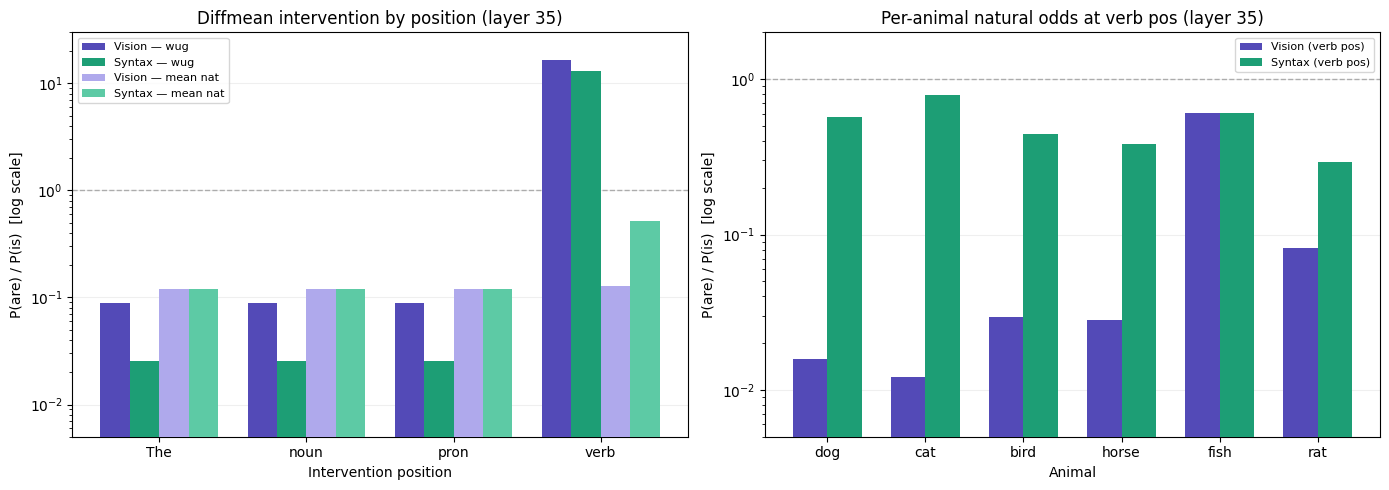

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Data from diffmean_rc_obj_full_results.json
# ==========================================================

positions = ["The", "noun", "pron", "verb"]

# P(are)/P(is) odds
vision_wug = [0.0896, 0.0896, 0.0896, 16.4533]
syntax_wug = [0.0257, 0.0257, 0.0257, 12.9742]
vision_nat = [0.1193, 0.1193, 0.1193, 0.1293]
syntax_nat = [0.1193, 0.1193, 0.1193, 0.5144]

animals = ["dog", "cat", "bird", "horse", "fish", "rat"]
vision_animal_verb = [0.0158, 0.0121, 0.0293, 0.0281, 0.6084, 0.0821]
syntax_animal_verb = [0.5681, 0.7925, 0.4457, 0.3807, 0.6084, 0.2908]

# ==========================================================
# Plot 1: Odds by position (wug + mean natural)
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(positions))
w = 0.2

ax = axes[0]
ax.bar(x - 1.5*w, vision_wug, w, label="Vision — wug", color="#534AB7", zorder=3)
ax.bar(x - 0.5*w, syntax_wug, w, label="Syntax — wug", color="#1D9E75", zorder=3)
ax.bar(x + 0.5*w, vision_nat, w, label="Vision — mean nat", color="#AFA9EC", zorder=3)
ax.bar(x + 1.5*w, syntax_nat, w, label="Syntax — mean nat", color="#5DCAA5", zorder=3)
ax.set_yscale("log")
ax.axhline(1.0, color="gray", ls="--", lw=1, alpha=0.6, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(positions)
ax.set_xlabel("Intervention position")
ax.set_ylabel("P(are) / P(is)  [log scale]")
ax.set_title("Diffmean intervention by position (layer 35)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=0.2, zorder=0)
ax.set_ylim(0.005, 30)

# ==========================================================
# Plot 2: Per-animal odds at verb position
# ==========================================================

x2 = np.arange(len(animals))
w2 = 0.35

ax2 = axes[1]
ax2.bar(x2 - w2/2, vision_animal_verb, w2, label="Vision (verb pos)", color="#534AB7", zorder=3)
ax2.bar(x2 + w2/2, syntax_animal_verb, w2, label="Syntax (verb pos)", color="#1D9E75", zorder=3)
ax2.set_yscale("log")
ax2.axhline(1.0, color="gray", ls="--", lw=1, alpha=0.6, zorder=2)
ax2.set_xticks(x2)
ax2.set_xticklabels(animals)
ax2.set_xlabel("Animal")
ax2.set_ylabel("P(are) / P(is)  [log scale]")
ax2.set_title("Per-animal natural odds at verb pos (layer 35)")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.2, zorder=0)
ax2.set_ylim(0.005, 2)

plt.tight_layout()
plt.savefig("diffmean_intervention_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
import pyvene as pv
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
import json
import os

# ==========================================================
# 0. Setup
# ==========================================================
model = lm.model
tokenizer = lm.tokenizer.tokenizer
hidden_size = model.language_model.config.hidden_size
device = "cuda"
num_layers = model.language_model.config.num_hidden_layers

added_tokens = [" [wug]", " [wugs]"]
existing_vocab = tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    tokenizer.add_tokens(tokens_to_add)
    old_len = model.resize_token_embeddings().weight.shape[0]
    model.resize_token_embeddings(old_len + len(tokens_to_add))
    print(f"Added tokens: {tokens_to_add}")
else:
    print("Tokens already in vocab")

is_id = tokenizer.encode(" is", add_special_tokens=False)[0]
are_id = tokenizer.encode(" are", add_special_tokens=False)[0]
print(f"is: {is_id}, are: {are_id}")

# ==========================================================
# 1. 50 sentence pairs ending with the noun
# ==========================================================

template_pairs = [
    # ── determiner / quantifier contrasts ──
    ("I saw a [SING]", "I saw many [PLUR]"),
    ("I found a [SING]", "I found several [PLUR]"),
    ("I caught a [SING]", "I caught two [PLUR]"),
    ("I held a [SING]", "I held three [PLUR]"),
    ("I fed a [SING]", "I fed some [PLUR]"),
    ("I watched a [SING]", "I watched many [PLUR]"),
    ("I heard a [SING]", "I heard several [PLUR]"),
    ("I chased a [SING]", "I chased two [PLUR]"),
    ("I named a [SING]", "I named three [PLUR]"),
    ("I raised a [SING]", "I raised many [PLUR]"),

    # ── "the" + singular vs "the" + plural ──
    ("I saw the [SING]", "I saw the [PLUR]"),
    ("I found the [SING]", "I found the [PLUR]"),
    ("I fed the [SING]", "I fed the [PLUR]"),
    ("I watched the [SING]", "I watched the [PLUR]"),
    ("I heard the [SING]", "I heard the [PLUR]"),

    # ── "this/that" vs "these/those" ──
    ("I saw this [SING]", "I saw these [PLUR]"),
    ("I found that [SING]", "I found those [PLUR]"),
    ("I caught this [SING]", "I caught these [PLUR]"),
    ("I held that [SING]", "I held those [PLUR]"),
    ("I fed this [SING]", "I fed these [PLUR]"),

    # ── "one" vs number ──
    ("I saw one [SING]", "I saw five [PLUR]"),
    ("I found one [SING]", "I found four [PLUR]"),
    ("I caught one [SING]", "I caught six [PLUR]"),
    ("I held one [SING]", "I held ten [PLUR]"),
    ("I heard one [SING]", "I heard eight [PLUR]"),

    # ── "each/every" vs "all/most" ──
    ("I fed each [SING]", "I fed all [PLUR]"),
    ("I watched every [SING]", "I watched all [PLUR]"),
    ("I named each [SING]", "I named most [PLUR]"),
    ("I raised every [SING]", "I raised most [PLUR]"),
    ("I chased each [SING]", "I chased all [PLUR]"),

    # ── "another" vs "more" ──
    ("I saw another [SING]", "I saw more [PLUR]"),
    ("I found another [SING]", "I found more [PLUR]"),
    ("I caught another [SING]", "I caught more [PLUR]"),
    ("I heard another [SING]", "I heard more [PLUR]"),
    ("I held another [SING]", "I held more [PLUR]"),

    # ── different subjects ──
    ("she saw a [SING]", "she saw many [PLUR]"),
    ("he found a [SING]", "he found several [PLUR]"),
    ("we caught a [SING]", "we caught two [PLUR]"),
    ("they held a [SING]", "they held three [PLUR]"),
    ("you fed a [SING]", "you fed some [PLUR]"),

    # ── different verbs ──
    ("I liked the [SING]", "I liked the [PLUR]"),
    ("I loved a [SING]", "I loved many [PLUR]"),
    ("I saved a [SING]", "I saved several [PLUR]"),
    ("I trained a [SING]", "I trained two [PLUR]"),
    ("I drew a [SING]", "I drew many [PLUR]"),

    # ── preposition phrases ──
    ("I sat near a [SING]", "I sat near many [PLUR]"),
    ("I stood beside a [SING]", "I stood beside two [PLUR]"),
    ("I walked past a [SING]", "I walked past several [PLUR]"),
    ("I ran from a [SING]", "I ran from many [PLUR]"),
    ("I hid behind a [SING]", "I hid behind three [PLUR]"),
]

assert len(template_pairs) == 50, f"Expected 50 pairs, got {len(template_pairs)}"

def slot_in(templates, sing_word, plur_word):
    """Replace [SING]/[PLUR] with actual words."""
    pairs = []
    for s_tmpl, p_tmpl in templates:
        pairs.append({
            "singular": s_tmpl.replace("[SING]", sing_word),
            "plural": p_tmpl.replace("[PLUR]", plur_word),
        })
    return pairs

# ==========================================================
# 2. Animal eval sets (dog/dogs is now training, not eval)
# ==========================================================

animal_pairs = {
    "fox/foxes": ("fox", "foxes"),
    "cat/cats": ("cat", "cats"),
    "bird/birds": ("bird", "birds"),
    "horse/horses": ("horse", "horses"),
    "rat/rats": ("rat", "rats"),
    "bear/bears": ("bear", "bears"),
}

print("\nAnimal tokenization check:")
for label, (sing, plur) in animal_pairs.items():
    s_toks = tokenizer.encode(f" {sing}", add_special_tokens=False)
    p_toks = tokenizer.encode(f" {plur}", add_special_tokens=False)
    ok = len(s_toks) == 1 and len(p_toks) == 1
    print(f"  {label}: sing={len(s_toks)} plur={len(p_toks)} {'OK' if ok else 'MULTI-TOKEN!'}")

# dog/dogs = training animal
dog_train_pairs = slot_in(template_pairs, "dog", "dogs")
wug_eval_pairs = slot_in(template_pairs, "[wug]", "[wugs]")

print(f"\nTraining pairs (dog/dogs): {len(dog_train_pairs)}")
print(f"Wug eval pairs: {len(wug_eval_pairs)}")

# ==========================================================
# 3. Tokenize
# ==========================================================

def tokenize_pair(singular_text, plural_text, tokenizer, device):
    src = tokenizer(plural_text, return_tensors="pt").to(device)
    base = tokenizer(singular_text, return_tensors="pt").to(device)
    return {
        "src": src, "base": base,
        "src_len": src.input_ids.shape[1],
        "base_len": base.input_ids.shape[1],
    }

dog_train_tok = [tokenize_pair(p["singular"], p["plural"], tokenizer, device)
                 for p in dog_train_pairs]
wug_eval_tok = [tokenize_pair(p["singular"], p["plural"], tokenizer, device)
                for p in wug_eval_pairs]

nat_eval_sets = {}
for animal_label, (sing, plur) in animal_pairs.items():
    nat_pairs = slot_in(template_pairs, sing, plur)
    nat_eval_sets[animal_label] = [tokenize_pair(p["singular"], p["plural"], tokenizer, device)
                                   for p in nat_pairs]

sample_pair = dog_train_tok[0]
print(f"\nSample singular: {tokenizer.decode(sample_pair['base'].input_ids[0])}")
print(f"Sample plural:   {tokenizer.decode(sample_pair['src'].input_ids[0])}")
print(f"  base_len={sample_pair['base_len']}, src_len={sample_pair['src_len']}")
print(f"  Predict position (next-token after last): base_len - 1 = {sample_pair['base_len'] - 1}")

# ==========================================================
# 4. DAS functions (intervene on final token = noun position)
# ==========================================================

def train_das_final_noun(model, train_pairs_tok, layer_i,
                         hidden_size, device, n_steps=300, lr=5e-3):
    rotate_layer = nn.Linear(hidden_size, 1, bias=False)
    nn.init.orthogonal_(rotate_layer.weight)
    rotate_layer = rotate_layer.to(device=device, dtype=torch.bfloat16)

    def das_fn(b, s):
        w = rotate_layer.weight
        a = (w / w.norm()).squeeze(0)
        bp = (b * a).sum(-1, keepdim=True)
        sp = (s * a).sum(-1, keepdim=True)
        return b + (sp - bp) * a

    pv_das = pv.IntervenableModel({
        "component": f"model.language_model.layers[{layer_i}].output",
        "intervention": das_fn,
    }, model=model)

    optimizer = torch.optim.Adam(rotate_layer.parameters(), lr=lr)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * n_steps), num_training_steps=n_steps
    )

    for param in model.parameters():
        param.requires_grad = False

    for step in range(n_steps):
        pair = train_pairs_tok[step % len(train_pairs_tok)]
        base_noun_pos = pair["base_len"] - 1
        src_noun_pos = pair["src_len"] - 1
        predict_pos = pair["base_len"] - 1

        _, out = pv_das(
            pair["base"], [pair["src"]],
            {"sources->base": ([[[src_noun_pos]]], [[[base_noun_pos]]])},
        )

        logits = out.logits[:, predict_pos, :]
        target = torch.tensor([are_id], device=device)
        loss = F.cross_entropy(logits.float(), target)

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    del pv_das
    return rotate_layer


def compute_odds_final_noun(model, eval_pairs_tok, rotate_layer,
                            layer_i, device, is_id, are_id):
    def das_fn(b, s):
        w = rotate_layer.weight
        a = (w / w.norm()).squeeze(0)
        bp = (b * a).sum(-1, keepdim=True)
        sp = (s * a).sum(-1, keepdim=True)
        return b + (sp - bp) * a

    pv_das = pv.IntervenableModel({
        "component": f"model.language_model.layers[{layer_i}].output",
        "intervention": das_fn,
    }, model=model)

    odds_list = []
    with torch.no_grad():
        for pair in eval_pairs_tok:
            base_noun_pos = pair["base_len"] - 1
            src_noun_pos = pair["src_len"] - 1
            predict_pos = pair["base_len"] - 1

            _, out = pv_das(
                pair["base"], [pair["src"]],
                {"sources->base": ([[[src_noun_pos]]], [[[base_noun_pos]]])},
            )

            probs = torch.softmax(out.logits[:, predict_pos, :].float(), dim=-1)
            p_are = probs[0, are_id].item()
            p_is = probs[0, is_id].item()

            if p_is > 1e-10:
                odds_list.append(p_are / p_is)

    del pv_das
    return sum(odds_list) / len(odds_list) if odds_list else 0.0

# ==========================================================
# 5. Run DAS: train on dog/dogs, eval on wug + animals
# ==========================================================

VISUAL_PATH_BEST = "embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST = "embeddings/SYNTAX_EMBEDDINGS.pt"

layers_to_test = list(range(0, num_layers))
print(f"\nLayers to test: {layers_to_test}")

RESULTS_FILE = "das_noun_final_dog_results.json"

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        save_data = json.load(f)
    all_das_results = save_data.get("results", {})
    print(f"Loaded existing results from {RESULTS_FILE}")
else:
    all_das_results = {}

for condition, embed_path in [("vision", VISUAL_PATH_BEST), ("syntax", SYNTAX_PATH_BEST)]:
    print(f"\n{'='*60}")
    print(f"DAS Condition: {condition.upper()} (train=dog, intervene=final noun)")
    print(f"{'='*60}")

    saved = torch.load(embed_path)
    emb = model.language_model.embed_tokens
    emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
    print(f"  [wug] norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
    print(f"  [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")

    if condition not in all_das_results:
        all_das_results[condition] = []

    done_layers = [r["layer"] for r in all_das_results[condition]]

    for layer_i in [35]:
        if layer_i in done_layers:
            print(f"  layer={layer_i:2d}: already done, skipping")
            continue

        print(f"  layer={layer_i:2d}:", end=" ")

        # Train on dog/dogs
        rotate_layer = train_das_final_noun(
            model, dog_train_tok, layer_i,
            hidden_size, device, n_steps=300, lr=5e-3
        )

        # Eval on dog (train set)
        odds_dog = compute_odds_final_noun(
            model, dog_train_tok, rotate_layer,
            layer_i, device, is_id, are_id
        )

        # Eval on wug/wugs
        odds_wug = compute_odds_final_noun(
            model, wug_eval_tok, rotate_layer,
            layer_i, device, is_id, are_id
        )

        # Eval on natural animals
        animal_odds = {}
        for animal_label, nat_tok in nat_eval_sets.items():
            animal_odds[animal_label] = compute_odds_final_noun(
                model, nat_tok, rotate_layer,
                layer_i, device, is_id, are_id
            )

        mean_nat = sum(animal_odds.values()) / len(animal_odds)

        print(f"dog={odds_dog:.4f} wug={odds_wug:.4f} mean_nat={mean_nat:.4f} " +
              " ".join(f"{k.split('/')[0]}={v:.4f}" for k, v in animal_odds.items()))

        all_das_results[condition].append({
            "layer": layer_i,
            "odds_dog_train": odds_dog,
            "odds_wug": odds_wug,
            "mean_natural": mean_nat,
            **{f"odds_{k}": v for k, v in animal_odds.items()},
        })

        torch.cuda.empty_cache()

    # Save after each condition
    save_data = {
        "method": "DAS",
        "train_animal": "dog/dogs",
        "intervene_position": "final_noun",
        "n_templates": len(template_pairs),
        "n_steps": 300,
        "layers": layers_to_test,
        "animals_eval": list(animal_pairs.keys()),
        "results": all_das_results,
    }
    with open(RESULTS_FILE, "w") as f:
        json.dump(save_data, f, indent=2)
    print(f"  -> Saved to {RESULTS_FILE}")

# ==========================================================
# 6. Final save
# ==========================================================
save_data = {
    "method": "DAS",
    "train_animal": "dog/dogs",
    "intervene_position": "final_noun",
    "n_templates": len(template_pairs),
    "n_steps": 300,
    "layers": layers_to_test,
    "animals_eval": list(animal_pairs.keys()),
    "results": all_das_results,
}
with open(RESULTS_FILE, "w") as f:
    json.dump(save_data, f, indent=2)
print(f"\nFinal save to {RESULTS_FILE}")

Tokens already in vocab
is: 374, are: 525

Animal tokenization check:
  fox/foxes: sing=1 plur=2 MULTI-TOKEN!
  cat/cats: sing=1 plur=1 OK
  bird/birds: sing=1 plur=1 OK
  horse/horses: sing=1 plur=1 OK
  rat/rats: sing=1 plur=1 OK
  bear/bears: sing=1 plur=1 OK

Training pairs (dog/dogs): 50
Wug eval pairs: 50

Sample singular: I saw a dog
Sample plural:   I saw many dogs
  base_len=4, src_len=4
  Predict position (next-token after last): base_len - 1 = 3

Layers to test: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]

DAS Condition: VISION (train=dog, intervene=final noun)
  [wug] norm: 1.0781
  [wugs] norm: 1.0781
  layer=35: dog=190515.4842 wug=13176739.9557 mean_nat=236932.7007 fox=1331334.6662 cat=15009.5145 bird=25673.3835 horse=7606.2576 rat=33218.3727 bear=8754.0095
  -> Saved to das_noun_final_dog_results.json

DAS Condition: SYNTAX (train=dog, intervene=final noun)
  [wug] norm: 1.3906
  

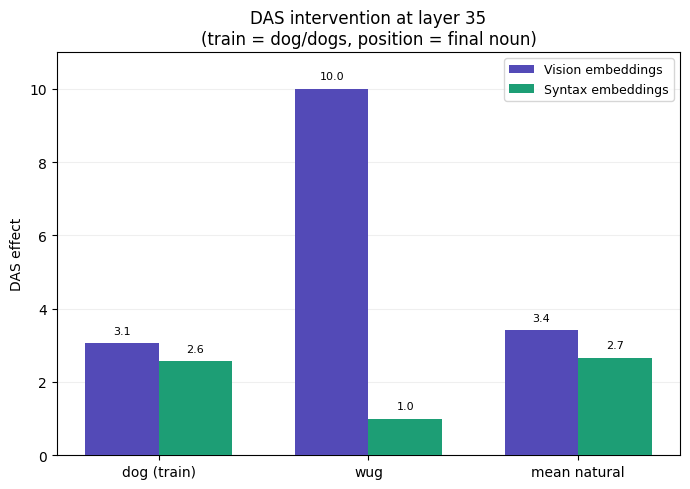

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Data: DAS noun-final, train=dog/dogs, layer 35
# ==========================================================

categories = ["dog (train)", "wug", "mean natural"]
vision_raw = np.array([190515.48, 13176739.96, 236932.70])
syntax_raw = np.array([141421.87, 54566.82, 150425.95])

# Scale to 1–10: log-transform then linear rescale
all_raw = np.concatenate([vision_raw, syntax_raw])
log_min = np.log10(all_raw.min())
log_max = np.log10(all_raw.max())
def scale(vals):
    return 1 + 9 * (np.log10(vals) - log_min) / (log_max - log_min)

vision = scale(vision_raw)
syntax = scale(syntax_raw)

x = np.arange(len(categories))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x - w/2, vision, w, label="Vision embeddings", color="#534AB7", zorder=3)
ax.bar(x + w/2, syntax, w, label="Syntax embeddings", color="#1D9E75", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("DAS effect")
ax.set_ylim(0, 11)
ax.set_title("DAS intervention at layer 35\n(train = dog/dogs, position = final noun)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.2, zorder=0)

for bars_data, offset in [(vision, -w/2), (syntax, w/2)]:
    for i, val in enumerate(bars_data):
        ax.text(x[i] + offset, val + 0.2, f"{val:.1f}",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("das_dog_layer35_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()